# Import libraries

In [1]:
import os
import warnings
import bisect
import gc
from copy import deepcopy
from collections import defaultdict

import psutil
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from kaggle.api.kaggle_api_extended import KaggleApi
from feature_engine.selection import DropConstantFeatures, DropDuplicateFeatures
from feature_engine.variable_handling import (
    find_categorical_variables,
    find_numerical_variables,
)

from kvbiii_plots.eda.categorical_plots import CategoricalPlots
from kvbiii_plots.eda.continuous_plots import ContinuousPlots
from kvbiii_plots.evaluation.regression_plots import RegressionPlots
from kvbiii_plots.ml.other_plots import OtherPlots
from kvbiii_plots.evaluation.shap_plots import SHAPPlots

from kvbiii_ml.data_processing.eda.data_analysis import DataAnalyzer
from kvbiii_ml.data_processing.eda.data_transformation import DataTransformer
from kvbiii_ml.data_processing.feature_engineering.case_normalizer import CaseNormalizer
from kvbiii_ml.data_processing.feature_engineering.categorical_aligner import CategoricalAligner
from kvbiii_ml.data_processing.feature_engineering.numerical_downcaster import NumericalDowncaster
from kvbiii_ml.data_processing.feature_engineering.digits_encoding import DigitsEncodingFeatureGenerator
from kvbiii_ml.data_processing.preprocessing.discretisation.kbins_discretiser import KBinsDiscretiserWithOriginal
from kvbiii_ml.data_processing.preprocessing.categorical_encoding.count_frequency_encoder import CountFrequencyEncoderWithOriginal
from kvbiii_ml.data_processing.preprocessing.categorical_encoding.target_encoder import TargetEncoderWithOriginal
from kvbiii_ml.data_processing.preprocessing.pipeline_dependency import build_restricted_pipeline

from kvbiii_ml.data_processing.feature_selection.model_importance_filtering import ModelImportanceFiltering
from kvbiii_ml.data_processing.feature_selection.permutation_feature_importance import PermutationRecursiveFeatureElimination

from kvbiii_ml.modeling.training.cross_validation import CrossValidationTrainer
from kvbiii_ml.modeling.training.ensemble_model import EnsembleModel
from kvbiii_ml.modeling.optimization.ensemble_weights_tuner import EnsembleWeightTunerCV
from kvbiii_ml.evaluation.generate_reports import regression_results
from kvbiii_ml.evaluation.shap_values import compute_shap_values

warnings.filterwarnings("ignore", category=UserWarning, message="Could not infer format")

data_analyzer = DataAnalyzer()
data_transformer = DataTransformer()
categorical_plots = CategoricalPlots()
continuous_plots = ContinuousPlots()
regression_plots = RegressionPlots()
other_plots = OtherPlots()
shap_plots = SHAPPlots()

SEED = 17
PROBLEM_TYPE = "regression"
METRIC_NAME = "RMSE"
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)
N_TRIALS = 100

cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, cv=CV, verbose=False)

# Load dataset

In [2]:
def load_data(folder_name: str = "data") -> tuple[pd.DataFrame, pd.DataFrame]:
    """Loads the train and test datasets from the specified folder."""
    train_csv = os.path.join(folder_name, "train.csv")
    test_csv = os.path.join(folder_name, "test.csv")
    train_df = pd.read_csv(train_csv, index_col="Id")
    test_df = pd.read_csv(test_csv, index_col="Id")
    return train_df, test_df


COMPETITION_NAME = "house-prices-advanced-regression-techniques"
train, test = load_data()
# train = train.sample(1000, random_state=SEED).reset_index(drop=True)
TARGET_FEATURE, train_data, test_data = "SalePrice", train, test
train_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


# Feature Engineering

In [3]:
train_data.columns = [ feature.upper().replace(" ", "_") for feature in train_data.columns ]
test_data.columns = [feature.upper().replace(" ", "_") for feature in test_data.columns]
features = train_data.columns.tolist()
features = [ (feature.upper().replace(" ", "_"), train_data[feature].dtype) for feature in features ]
TARGET_FEATURE = TARGET_FEATURE.upper().replace(" ", "_")

## Target Log Transformation

In [4]:
train_data[TARGET_FEATURE] = np.log1p(train_data[TARGET_FEATURE])

## Feature generation

The EDA repeatedly surfaced three actionable, recurring patterns that this feature set targets directly: (1) around 15 categorical columns (`EXTERQUAL`, `BSMTQUAL`, `GARAGEFINISH`, `FUNCTIONAL`, `LOTSHAPE`, `PAVEDDRIVE`, `FENCE`, etc.) have an explicit natural quality/condition ranking, which a GBM exploits far more efficiently as one ordinal column than as several one-hot splits; (2) `OVERALLQUAL`, `GRLIVAREA`, `YEARBUILT`, `TOTALBSMTSF`, `GARAGECARS`, and `FIREPLACES` are the strongest individual predictors (Spearman 0.5-0.81) and were each explicitly flagged for pairing as interaction features; and (3) several zero-inflated area/count columns (`2NDFLRSF`, `WOODDECKSF`, `OPENPORCHSF`, `ENCLOSEDPORCH`, `MASVNRAREA`, `FIREPLACES`) benefit from a presence flag that isolates the has/doesn't-have effect in a single split. On top of that, Ames-specific domain knowledge contributes well-known composites (`TOTAL_LIVING_AREA_SQFT` = GrLivArea + TotalBsmtSF, weighted `TOTAL_BATHROOMS`, house/remodel/garage age at sale) and fixed data-dictionary mappings (MSSubClass building-era codes, Condition1/2 railroad/positive-feature proximity codes) that a purely statistical encoder cannot recover on its own. Two size flags (large lot, spacious living area) use a frozen 90th/75th percentile of `train_data`'s own `LOTAREA`/`GRLIVAREA`, since no universal real-world cutoff exists for what counts as "large" in Ames.

In [5]:
QUALITY_ORDINAL_MAP: dict[str, int] = {"PO": 1, "FA": 2, "TA": 3, "GD": 4, "EX": 5}
BSMT_EXPOSURE_ORDINAL_MAP: dict[str, int] = {"NO": 1, "MN": 2, "AV": 3, "GD": 4}
BSMT_FINTYPE_ORDINAL_MAP: dict[str, int] = {"UNF": 1, "LWQ": 2, "REC": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
GARAGE_FINISH_ORDINAL_MAP: dict[str, int] = {"UNF": 1, "RFN": 2, "FIN": 3}
FUNCTIONAL_ORDINAL_MAP: dict[str, int] = {
    "SAL": 0, "SEV": 1, "MAJ2": 2, "MAJ1": 3, "MOD": 4, "MIN2": 5, "MIN1": 6, "TYP": 7,
}
LOT_SHAPE_ORDINAL_MAP: dict[str, int] = {"IR3": 0, "IR2": 1, "IR1": 2, "REG": 3}
LAND_SLOPE_ORDINAL_MAP: dict[str, int] = {"SEV": 0, "MOD": 1, "GTL": 2}
UTILITIES_ORDINAL_MAP: dict[str, int] = {"ELO": 0, "NOSEWA": 1, "NOSEWR": 2, "ALLPUB": 3}
PAVED_DRIVE_ORDINAL_MAP: dict[str, int] = {"N": 0, "P": 1, "Y": 2}
FENCE_ORDINAL_MAP: dict[str, int] = {"MNWW": 1, "GDWO": 2, "MNPRV": 3, "GDPRV": 4}

NEWER_BUILD_MSSUBCLASS_CODES: set[int] = {20, 60, 120, 160}
MULTI_FAMILY_MSSUBCLASS_CODES: set[int] = {90, 190}
POSITIVE_LOCATION_CONDITION_CODES: set[str] = {"POSA", "POSN"}
RAILROAD_ADJACENT_CONDITION_CODES: set[str] = {"RRNN", "RRAN", "RRNE", "RRAE"}

HALF_BATH_WEIGHT: float = 0.5
NEW_HOME_AGE_THRESHOLD_YEARS: int = 5
RECENT_REMODEL_THRESHOLD_YEARS: int = 5
LARGE_LOT_AREA_CUTOFF_SQFT: float = round(train_data["LOTAREA"].quantile(0.90), -2)
SPACIOUS_LIVING_AREA_CUTOFF_SQFT: float = round(train_data["GRLIVAREA"].quantile(0.75), -2)


def _map_ordinal_category(series: pd.Series, ordinal_map: dict[str, int]) -> pd.Series:
    """
    Maps a categorical series to a fixed domain ordinal scale.

    Unmapped or missing values are encoded as 0, matching the dataset convention that a
    missing quality/finish category represents structural absence of that feature (e.g. no
    basement, no garage), which ranks below the worst present category.

    Args:
        series (pd.Series): Raw categorical column to encode.
        ordinal_map (dict[str, int]): Fixed domain-knowledge mapping from uppercased category
            code to its ordinal rank.

    Returns:
        pd.Series: Integer ordinal encoding of the input series.
    """
    return series.str.upper().map(ordinal_map).fillna(0).astype(int)


def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich the Ames housing dataset with ordinal quality encodings, size/age composites, and
    domain-driven interaction and presence features.

    Every derived feature is computed independently for each row from either the row's own
    values or fixed real-world/domain constants (quality-scale rankings, half-bath weighting,
    MSSubClass building-era codes, condition proximity codes) plus two size cutoffs frozen once
    from `train_data`'s own unsupervised quantiles (LOTAREA, GRLIVAREA -- never the target). No
    statistic is fitted on `df` itself, so this function is safe to call separately on each
    cross-validation fold, on the held-out fold, and on the test set without leaking information
    across folds.

    Args:
        df (pd.DataFrame): Raw input dataframe containing the uppercased Ames housing columns.

    Returns:
        pd.DataFrame: Copy of the input dataframe enriched with additional engineered feature
            columns. The target column, if present, is left untouched.
    """
    df = df.copy()

    df["EXTERQUAL_ORDINAL"] = _map_ordinal_category(df["EXTERQUAL"], QUALITY_ORDINAL_MAP)
    df["EXTERCOND_ORDINAL"] = _map_ordinal_category(df["EXTERCOND"], QUALITY_ORDINAL_MAP)
    df["HEATINGQC_ORDINAL"] = _map_ordinal_category(df["HEATINGQC"], QUALITY_ORDINAL_MAP)
    df["KITCHENQUAL_ORDINAL"] = _map_ordinal_category(df["KITCHENQUAL"], QUALITY_ORDINAL_MAP)
    df["BSMTQUAL_ORDINAL"] = _map_ordinal_category(df["BSMTQUAL"], QUALITY_ORDINAL_MAP)
    df["BSMTCOND_ORDINAL"] = _map_ordinal_category(df["BSMTCOND"], QUALITY_ORDINAL_MAP)
    df["GARAGEQUAL_ORDINAL"] = _map_ordinal_category(df["GARAGEQUAL"], QUALITY_ORDINAL_MAP)
    df["GARAGECOND_ORDINAL"] = _map_ordinal_category(df["GARAGECOND"], QUALITY_ORDINAL_MAP)
    df["FIREPLACEQU_ORDINAL"] = _map_ordinal_category(df["FIREPLACEQU"], QUALITY_ORDINAL_MAP)
    df["POOLQC_ORDINAL"] = _map_ordinal_category(df["POOLQC"], QUALITY_ORDINAL_MAP)
    df["BSMTEXPOSURE_ORDINAL"] = _map_ordinal_category(df["BSMTEXPOSURE"], BSMT_EXPOSURE_ORDINAL_MAP)
    df["BSMTFINTYPE1_ORDINAL"] = _map_ordinal_category(df["BSMTFINTYPE1"], BSMT_FINTYPE_ORDINAL_MAP)
    df["BSMTFINTYPE2_ORDINAL"] = _map_ordinal_category(df["BSMTFINTYPE2"], BSMT_FINTYPE_ORDINAL_MAP)
    df["GARAGEFINISH_ORDINAL"] = _map_ordinal_category(df["GARAGEFINISH"], GARAGE_FINISH_ORDINAL_MAP)
    df["FUNCTIONAL_ORDINAL"] = _map_ordinal_category(df["FUNCTIONAL"], FUNCTIONAL_ORDINAL_MAP)
    df["LOTSHAPE_ORDINAL"] = _map_ordinal_category(df["LOTSHAPE"], LOT_SHAPE_ORDINAL_MAP)
    df["LANDSLOPE_ORDINAL"] = _map_ordinal_category(df["LANDSLOPE"], LAND_SLOPE_ORDINAL_MAP)
    df["UTILITIES_ORDINAL"] = _map_ordinal_category(df["UTILITIES"], UTILITIES_ORDINAL_MAP)
    df["PAVEDDRIVE_ORDINAL"] = _map_ordinal_category(df["PAVEDDRIVE"], PAVED_DRIVE_ORDINAL_MAP)
    df["FENCE_ORDINAL"] = _map_ordinal_category(df["FENCE"], FENCE_ORDINAL_MAP)

    df["QUALITY_RATINGS_COMPOSITE_SCORE"] = (
        df["EXTERQUAL_ORDINAL"] + df["KITCHENQUAL_ORDINAL"] + df["BSMTQUAL_ORDINAL"]
        + df["HEATINGQC_ORDINAL"] + df["GARAGEQUAL_ORDINAL"]
    )

    df["TOTAL_LIVING_AREA_SQFT"] = df["GRLIVAREA"] + df["TOTALBSMTSF"]
    df["TOTAL_LIVING_AREA_SQFT_LOG1P"] = np.log1p(df["TOTAL_LIVING_AREA_SQFT"].clip(lower=0))
    df["TOTAL_BATHROOMS"] = (
        df["FULLBATH"] + df["HALFBATH"] * HALF_BATH_WEIGHT
        + df["BSMTFULLBATH"] + df["BSMTHALFBATH"] * HALF_BATH_WEIGHT
    )
    df["TOTAL_PORCH_AREA_SQFT"] = (
        df["WOODDECKSF"] + df["OPENPORCHSF"] + df["ENCLOSEDPORCH"]
        + df["3SSNPORCH"] + df["SCREENPORCH"]
    )

    df["HOUSE_AGE_AT_SALE_YEARS"] = (df["YRSOLD"] - df["YEARBUILT"]).clip(lower=0)
    df["YEARS_SINCE_REMODEL_AT_SALE"] = (df["YRSOLD"] - df["YEARREMODADD"]).clip(lower=0)
    df["REMODEL_LAG_YEARS"] = (df["YEARREMODADD"] - df["YEARBUILT"]).clip(lower=0)
    df["WAS_REMODELED_FLAG"] = (df["YEARREMODADD"] > df["YEARBUILT"]).astype(int)
    df["GARAGE_AGE_AT_SALE_YEARS"] = (df["YRSOLD"] - df["GARAGEYRBLT"]).clip(lower=0)
    df["HAS_GARAGE_FLAG"] = df["GARAGETYPE"].notna().astype(int)
    df["IS_RECENTLY_BUILT_FLAG"] = (
        df["HOUSE_AGE_AT_SALE_YEARS"] <= NEW_HOME_AGE_THRESHOLD_YEARS
    ).astype(int)
    df["IS_RECENTLY_REMODELED_FLAG"] = (
        df["YEARS_SINCE_REMODEL_AT_SALE"] <= RECENT_REMODEL_THRESHOLD_YEARS
    ).astype(int)

    df["LOT_DEPTH_APPROX_FT"] = df["LOTAREA"] / (df["LOTFRONTAGE"] + 1)
    df["LIVING_AREA_TO_LOT_AREA_RATIO"] = df["GRLIVAREA"] / (df["LOTAREA"] + 1)
    df["BASEMENT_TO_LIVING_AREA_RATIO"] = df["TOTALBSMTSF"] / (df["GRLIVAREA"] + 1)
    df["BEDROOM_TO_ROOM_RATIO"] = df["BEDROOMABVGR"] / (df["TOTRMSABVGRD"] + 1)
    df["LIVING_AREA_PER_ROOM_SQFT"] = df["GRLIVAREA"] / (df["TOTRMSABVGRD"] + 1)
    df["GARAGE_AREA_PER_CAR_SQFT"] = df["GARAGEAREA"] / (df["GARAGECARS"] + 1)
    df["HAS_LARGE_LOT_FLAG"] = (df["LOTAREA"] > LARGE_LOT_AREA_CUTOFF_SQFT).astype(int)
    df["HAS_SPACIOUS_LIVING_AREA_FLAG"] = (
        df["GRLIVAREA"] > SPACIOUS_LIVING_AREA_CUTOFF_SQFT
    ).astype(int)

    df["HAS_2NDFLOOR_FLAG"] = (df["2NDFLRSF"] > 0).astype(int)
    df["HAS_BASEMENT_FLAG"] = (df["TOTALBSMTSF"] > 0).astype(int)
    df["HAS_MASONRY_VENEER_FLAG"] = (df["MASVNRAREA"].fillna(0) > 0).astype(int)
    df["HAS_FIREPLACE_FLAG"] = (df["FIREPLACES"] > 0).astype(int)
    df["HAS_WOODDECK_FLAG"] = (df["WOODDECKSF"] > 0).astype(int)
    df["HAS_OPENPORCH_FLAG"] = (df["OPENPORCHSF"] > 0).astype(int)
    df["HAS_ENCLOSEDPORCH_FLAG"] = (df["ENCLOSEDPORCH"] > 0).astype(int)
    df["HAS_MULTIPLE_KITCHENS_FLAG"] = (df["KITCHENABVGR"] > 1).astype(int)
    df["OUTDOOR_AMENITY_SCORE"] = (
        df["HAS_WOODDECK_FLAG"] + df["HAS_OPENPORCH_FLAG"] + df["HAS_FIREPLACE_FLAG"]
    )

    df["MSSUBCLASS_IS_NEWER_BUILD_FLAG"] = df["MSSUBCLASS"].isin(NEWER_BUILD_MSSUBCLASS_CODES).astype(int)
    df["MSSUBCLASS_IS_MULTI_FAMILY_FLAG"] = df["MSSUBCLASS"].isin(MULTI_FAMILY_MSSUBCLASS_CODES).astype(int)

    condition1_upper = df["CONDITION1"].str.upper()
    condition2_upper = df["CONDITION2"].str.upper()
    df["HAS_POSITIVE_LOCATION_FEATURE_FLAG"] = (
        condition1_upper.isin(POSITIVE_LOCATION_CONDITION_CODES)
        | condition2_upper.isin(POSITIVE_LOCATION_CONDITION_CODES)
    ).astype(int)
    df["HAS_RAILROAD_ADJACENCY_FLAG"] = (
        condition1_upper.isin(RAILROAD_ADJACENT_CONDITION_CODES)
        | condition2_upper.isin(RAILROAD_ADJACENT_CONDITION_CODES)
    ).astype(int)

    df["OVERALLQUAL_LIVING_AREA_INTERACTION"] = df["OVERALLQUAL"] * df["GRLIVAREA"]
    df["OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION"] = (
        df["OVERALLQUAL"] * df["TOTAL_LIVING_AREA_SQFT"]
    )
    df["OVERALLQUAL_HOUSE_AGE_INTERACTION"] = df["OVERALLQUAL"] * df["HOUSE_AGE_AT_SALE_YEARS"]

    return df


train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

In [6]:
NUNIQUE_BIN_THRESHOLDS = (10, 100, 500)


def get_feature_groups(
    data: pd.DataFrame, target_feature: str
) -> tuple[list[str], list[str], list[str]]:
    """
    Splits a DataFrame's columns into independent, categorical, and numerical feature groups.

    Args:
        data (pd.DataFrame): The full dataset, including the target column.
        target_feature (str): Name of the target column to exclude from the feature groups.

    Returns:
        tuple[list[str], list[str], list[str]]: Independent, categorical, and numerical features.

    Raises:
        AssertionError: If categorical and numerical features do not together cover all
            independent features.
    """
    independent_feats = data.drop(columns=[target_feature]).columns.tolist()
    categorical_feats = find_categorical_variables(data[independent_feats], return_empty=True)
    numerical_feats = find_numerical_variables(data[independent_feats], return_empty=True)

    if set(categorical_feats) | set(numerical_feats) != set(independent_feats):
        raise AssertionError(
            "Categorical and numerical features do not cover all independent features."
        )

    return independent_feats, categorical_feats, numerical_feats

def group_features_by_n_bins(data: pd.DataFrame, features: list[str]) -> dict[int, list[str]]:
    """
    Groups numerical features by every quantile bin count their cardinality supports.

    A feature qualifies for a bin count `n_bins` (drawn from `NUNIQUE_BIN_THRESHOLDS`) whenever
    its cardinality is at least `n_bins`, so a high-cardinality feature can be discretised at
    several granularities at once (e.g. 13214 unique values qualifies for 10, 100, and 500 bins).
    A feature below the smallest threshold qualifies for none and is left unbinned.

    Args:
        data (pd.DataFrame): The dataset containing `features`.
        features (list[str]): Numerical feature names to group.

    Returns:
        dict[int, list[str]]: Quantile bin count mapped to the features that qualify for it.
    """
    features_by_n_bins: dict[int, list[str]] = defaultdict(list)
    features_with_nans = []
    for train_index, _ in CV.split(data, data[TARGET_FEATURE]):
        X_train_cv = data.iloc[train_index]
        features_with_nans.append(X_train_cv[features].columns[X_train_cv[features].isnull().all()].tolist())
    features_with_nans = list(set([item for sublist in features_with_nans for item in sublist]))
    features = [feature for feature in features if feature not in features_with_nans]
    for feature in features:
        nunique = data[feature].nunique(dropna=False)
        n_qualifying = bisect.bisect_right(NUNIQUE_BIN_THRESHOLDS, nunique)
        for n_bins in NUNIQUE_BIN_THRESHOLDS[:n_qualifying]:
            features_by_n_bins[n_bins].append(feature)
    features_by_n_bins = dict(features_by_n_bins)
    features_by_n_bins["low_variance_numerical_features"] = [feature for feature in features if feature not in features_by_n_bins[10]]
    return features_by_n_bins


independent_features, categorical_features, numerical_features = get_feature_groups(train_data, TARGET_FEATURE)
features_by_n_bins = group_features_by_n_bins(train_data, numerical_features)

## Initial preprocessing pipeline

In [7]:
initial_preprocessing_pipeline = Pipeline(
    steps=[
        ("numerical_downcaster", NumericalDowncaster(numerical_features)),
        (
            "case_normalizer",
            CaseNormalizer(features_names=categorical_features, normalization="upper"),
        ),
        (
            "digits_encoder",
            DigitsEncodingFeatureGenerator(features_names=numerical_features),
        )
    ]
)

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train = initial_preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test = initial_preprocessing_pipeline.transform(X=X_test)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = (
    pd.concat([X_test, test_data[TARGET_FEATURE]], axis=1)
    if TARGET_FEATURE in test_data.columns
    else X_test.copy()
)
independent_features, categorical_features, numerical_features = get_feature_groups(train_data, TARGET_FEATURE)
features_by_n_bins = group_features_by_n_bins(train_data, numerical_features)
train_data

,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,...,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_1,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_2,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_3,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_4,OVERALLQUAL_TOTAL_LIVING_AREA_INTERACTION_PREPROCESS_DIGIT_5,OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_0,OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_1,OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_2,OVERALLQUAL_HOUSE_AGE_INTERACTION_PREPROCESS_DIGIT_3,SALEPRICE
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,6,9,7,1,0,5,3,0,0,12.247699
2,20,RL,80.0,9600,PAVE,<NA>,REG,LVL,ALLPUB,FR2,...,4,1,5,1,0,6,8,1,0,12.109016
3,60,RL,68.0,11250,PAVE,<NA>,IR1,LVL,ALLPUB,INSIDE,...,4,9,8,1,0,9,4,0,0,12.317171
4,70,RL,60.0,9550,PAVE,<NA>,IR1,LVL,ALLPUB,CORNER,...,1,3,7,1,0,7,3,6,0,11.849405
5,60,RL,84.0,14260,PAVE,<NA>,IR1,LVL,ALLPUB,FR2,...,4,7,6,2,0,4,6,0,0,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,0,6,5,1,0,8,4,0,0,12.072547
1457,20,RL,85.0,13175,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,9,6,1,2,0,2,9,1,0,12.254868
1458,70,RL,66.0,9042,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,4,4,4,2,0,3,8,4,0,12.493133


## Automated feature engineering pipeline

In [8]:
pipeline_steps = [
    (
        "categorical_aligner",
        CategoricalAligner(
            categorical_features=categorical_features,
            fill_strategy="constant",
            default_value="MISSING",
            warn_on_unknown=False,
        ),
    )
]

for n_bins in NUNIQUE_BIN_THRESHOLDS:
    if n_bins in features_by_n_bins:
        pipeline_steps.append(
            (
                f"kbins_discretiser_{n_bins}",
                KBinsDiscretiserWithOriginal(
                    variables=features_by_n_bins[n_bins],
                    n_bins=n_bins,
                    random_state=SEED,
                    missing_values="ignore",
                ),
            )
        )

if "low_variance_numerical_features" in features_by_n_bins:
    encoded_features = categorical_features + features_by_n_bins[
        "low_variance_numerical_features"
    ]

    if encoded_features:
        pipeline_steps.extend(
            [
                (
                    "count_frequency_encoder",
                    CountFrequencyEncoderWithOriginal(
                        encoding_method="frequency",
                        variables=encoded_features,
                        missing_values="ignore"
                    ),
                ),
                (
                    "target_encoder",
                    TargetEncoderWithOriginal(
                        variables=encoded_features,
                        smooth=10,
                        cv=CV,
                    ),
                ),
            ]
        )

pipeline_steps.append(("numerical_downcaster", NumericalDowncaster()))

preprocessing_pipeline = Pipeline(steps=pipeline_steps)

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train_transformed = preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test_transformed = preprocessing_pipeline.transform(X=X_test)
print(f"Number of features after preprocessing: {X_train_transformed.shape[1]}")

Number of features after preprocessing: 958


## Drop constant and duplicated features

In [9]:
def extract_source_features(columns: list[str], suffix: str) -> list[str]:
    """
    Recover the source feature names that produced derived columns ending in ``suffix``.


    Uses ``str.endswith`` rather than ``str.split`` so feature names that happen to
    contain the suffix string internally are handled correctly.

    Args:
        columns (list[str]): Column names from the post-transformation DataFrame.
        suffix (str): The full column suffix to match, e.g. ``"_PREPROCESS_WINSORIZER"``.

    Returns:
        list[str]: Sorted, deduplicated list of source feature names.
    """
    return sorted({col[: -len(suffix)] for col in columns if col.endswith(suffix)})


drop_features_pipeline = Pipeline(
    steps=[
        ("drop_constant_features", DropConstantFeatures(missing_values="ignore")),
        ("drop_duplicate_features", DropDuplicateFeatures()),
    ]
)
X_train_final = drop_features_pipeline.fit_transform(X_train_transformed, y_train)
X_test_final = drop_features_pipeline.transform(X_test_transformed)

surviving_features = sorted(set(X_train_final.columns) & set(X_test_final.columns))
X_train_final = X_train_final[surviving_features].copy()
X_test_final = X_test_final[surviving_features].copy()
print(f"Features after dropping constant and duplicates: {len(surviving_features)} / {X_train_transformed.shape[1]} ({len(surviving_features) / X_train_transformed.shape[1]:.1%})")

preprocessing_pipeline = build_restricted_pipeline(preprocessing_pipeline, X_train, y=y_train, selected_features=surviving_features)
original_input_surviving_features = sorted(set(independent_features) & set(preprocessing_pipeline[0].kw_args['features']))
train_data = train_data[original_input_surviving_features + [TARGET_FEATURE]].copy()
test_data = test_data[original_input_surviving_features + [TARGET_FEATURE]].copy() if TARGET_FEATURE in test_data.columns else test_data[original_input_surviving_features].copy()

Features after dropping constant and duplicates: 745 / 958 (77.8%)


In [10]:
independent_features, categorical_features, numerical_features = get_feature_groups(train_data, TARGET_FEATURE)
features_by_n_bins = group_features_by_n_bins(train_data, numerical_features)

## Memory reduction

In [11]:
def print_memory_usage(stage: str) -> None:
    """
    Print process and system memory usage in a readable format.

    Args:
        stage (str): Label describing when the snapshot is taken.
    """
    process = psutil.Process()
    rss_mb = process.memory_info().rss / (1024**2)
    virtual_memory = psutil.virtual_memory()
    available_mb = virtual_memory.available / (1024**2)
    print(f"[{stage}] Process RSS: {rss_mb:,.2f} MB | " f"Available RAM: {available_mb:,.2f} MB | " f"RAM used: {virtual_memory.percent:.1f}%")

def convert_category_to_object(dataframe: pd.DataFrame, dataframe_name: str) -> int:
    """
    Convert all category columns in a dataframe to object and print conversion details.

    Args:
        dataframe (pd.DataFrame): Dataframe to update.
        dataframe_name (str): Friendly dataframe name for logs.

    Returns:
        int: Number of converted columns.
    """
    category_columns = dataframe.select_dtypes(include=["category"]).columns.tolist()

    if not category_columns:
        print(f"{dataframe_name}: no 'category' columns found.")
        return 0

    dataframe[category_columns] = dataframe[category_columns].astype("object")
    print(f"{dataframe_name}: converted {len(category_columns)} column(s) " f"from 'category' to 'object': {category_columns}")
    return len(category_columns)

print_memory_usage("Before conversion")
train_converted_count = convert_category_to_object(train_data, "train_data")
test_converted_count = convert_category_to_object(test_data, "test_data")
print(f"Total converted columns: {train_converted_count + test_converted_count} " f"(train={train_converted_count}, test={test_converted_count})")
collected_objects = gc.collect()
print(f"Garbage collector reclaimed {collected_objects:,} unreachable object(s).")
print_memory_usage("After conversion")

[Before conversion] Process RSS: 419.14 MB | Available RAM: 47,669.03 MB | RAM used: 25.7%
train_data: no 'category' columns found.
test_data: no 'category' columns found.
Total converted columns: 0 (train=0, test=0)
Garbage collector reclaimed 108 unreachable object(s).
[After conversion] Process RSS: 419.14 MB | Available RAM: 47,667.07 MB | RAM used: 25.7%


# Summary of data analysis

In [12]:
data_analyzer.base_information(train_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,1STFLRSF,int16,0,0.00%,753,"1,460"
1,1STFLRSF_PREPROCESS_DIGIT_0,int8,0,0.00%,10,"1,460"
2,1STFLRSF_PREPROCESS_DIGIT_1,int8,0,0.00%,10,"1,460"
3,1STFLRSF_PREPROCESS_DIGIT_2,int8,0,0.00%,10,"1,460"
4,1STFLRSF_PREPROCESS_DIGIT_3,int8,0,0.00%,5,"1,460"
5,2NDFLRSF,int16,0,0.00%,417,"1,460"
6,2NDFLRSF_PREPROCESS_DIGIT_0,int8,0,0.00%,10,"1,460"
7,2NDFLRSF_PREPROCESS_DIGIT_1,int8,0,0.00%,10,"1,460"
8,2NDFLRSF_PREPROCESS_DIGIT_2,int8,0,0.00%,10,"1,460"
9,2NDFLRSF_PREPROCESS_DIGIT_3,int8,0,0.00%,3,"1,460"


# Feature selection

In [13]:
cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, preprocessing_pipeline=preprocessing_pipeline, cv=CV, verbose=False)

In [14]:
lgbm_model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=80,
    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,
    reg_alpha=0.15,
    reg_lambda=1.50,
    max_bin=255,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
    deterministic=True,
    force_col_wise=True,
    importance_type="gain",
    early_stopping_round=100
)
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=6.0,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=2.0,
    gamma=0.0,
    max_bin=256,
    enable_categorical=True,
    tree_method="hist",
    device="cuda",
    random_state=SEED,
    n_jobs=-1,
    early_stopping_rounds=50,
)
catboost_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=SEED,
    cat_features=categorical_features,
    task_type="GPU",
    iterations = 11000,
    early_stopping_rounds = 500,
    allow_writing_files=False,
    verbose=0,
    learning_rate = 0.015,
    depth = 8,
    l2_leaf_reg = 8.5,
    random_strength = 0.65,
    bagging_temperature = 0.45,
    bootstrap_type = "Bayesian",
    grow_policy = "SymmetricTree",
    border_count = 254,
    one_hot_max_size = 10,
    min_data_in_leaf = 48,
    max_ctr_complexity = 4,
)
estimators = [lgbm_model, xgb_model]
feature_selection_model = EnsembleModel(estimators=estimators, problem_type=PROBLEM_TYPE)

🔍 Starting Model Importance Stepwise Filtering with 745 features, target metric: RMSE (minimize), threshold: 0.0, max_steps: 10.

🛡️  Protected features: []
📊 Initial RMSE: 0.126536 ± 0.004933 | Features: 745

🔁 Step 1 | Features remaining: 745
📊 Average RMSE: 0.126536 ± 0.004933

🔬 Features remaining: ['1STFLRSF', '1STFLRSF_PREPROCESS_DIGIT_0', '1STFLRSF_PREPROCESS_DIGIT_0_PREPROCESS_KBINS_10', '1STFLRSF_PREPROCESS_DIGIT_1', '1STFLRSF_PREPROCESS_DIGIT_1_PREPROCESS_KBINS_10', '1STFLRSF_PREPROCESS_DIGIT_2', '1STFLRSF_PREPROCESS_DIGIT_2_PREPROCESS_KBINS_10', '1STFLRSF_PREPROCESS_DIGIT_3', '1STFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_CNT_FREQ', '1STFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', '1STFLRSF_PREPROCESS_KBINS_10', '1STFLRSF_PREPROCESS_KBINS_100', '1STFLRSF_PREPROCESS_KBINS_500', '2NDFLRSF', '2NDFLRSF_PREPROCESS_DIGIT_0', '2NDFLRSF_PREPROCESS_DIGIT_0_PREPROCESS_KBINS_10', '2NDFLRSF_PREPROCESS_DIGIT_1', '2NDFLRSF_PREPROCESS_DIGIT_1_PREPROCESS_KBINS_10', '2NDFLRSF_PREPROCESS_DIGIT_2

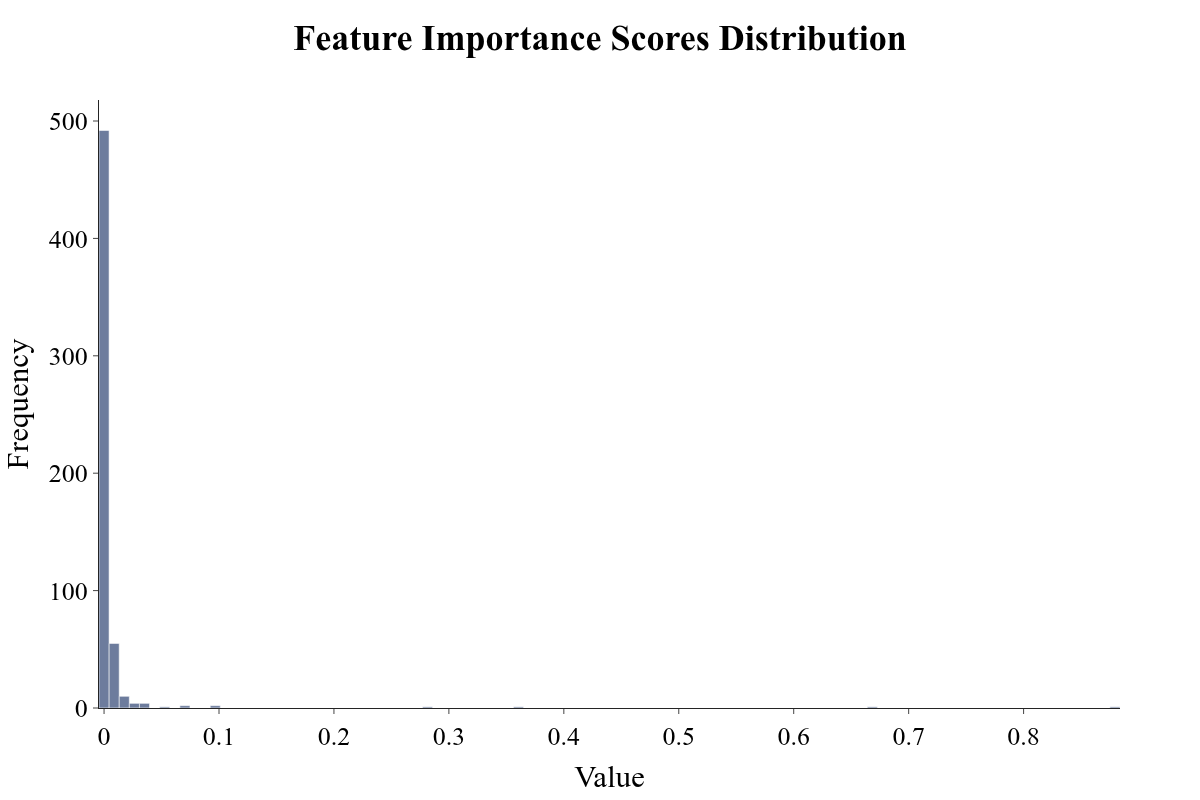

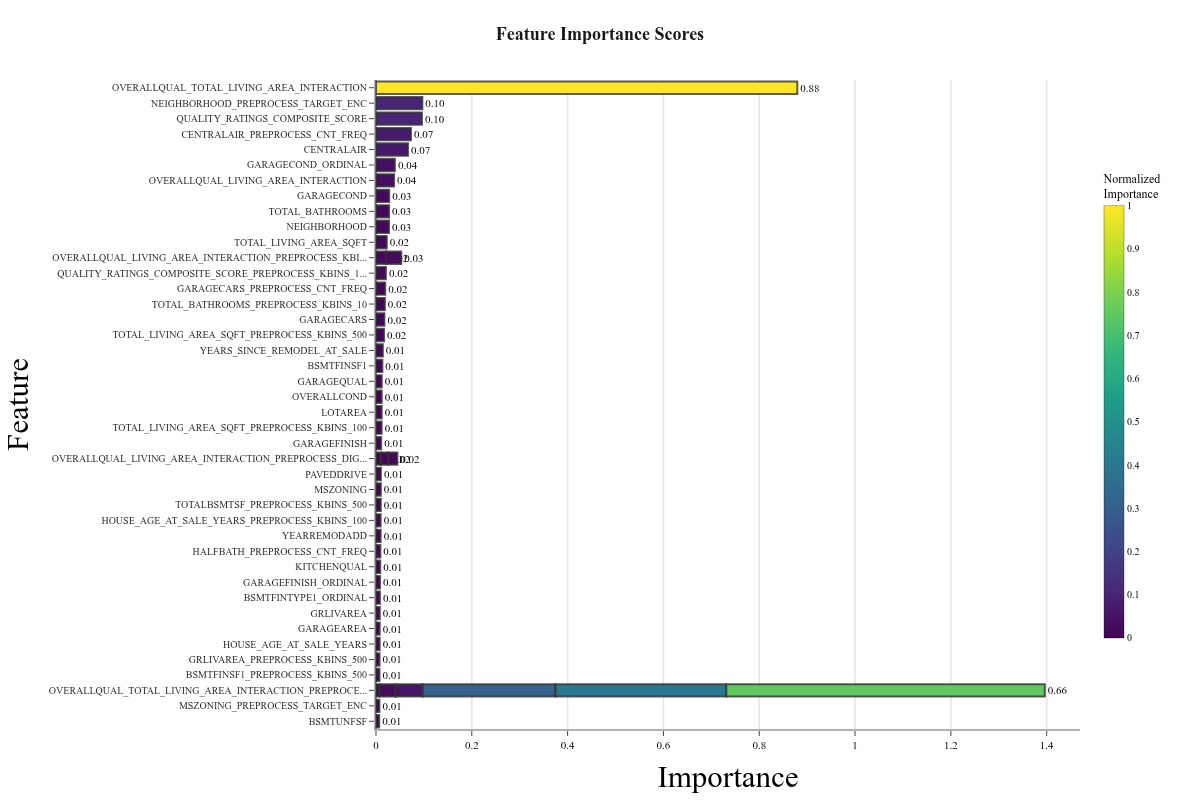

In [15]:
model_importance_filtering = ModelImportanceFiltering( estimator=feature_selection_model, cross_validator=cross_validation_trainer, threshold=0.00, verbose=True)

model_importance_filtering_summary = model_importance_filtering.run( train_data[independent_features], train_data[TARGET_FEATURE] )
model_importance_filtering_summary_history = model_importance_filtering_summary[ "history" ].copy()
model_importance_filtering_selected_features = model_importance_filtering_summary[ "selected_features" ].copy()
print(f"Number of selected features: {len(model_importance_filtering_selected_features)} ({len(model_importance_filtering_selected_features)/len(independent_features)*100:.2f}% of total features)")
print("Top 5 most important features:")
for feature, score in sorted(
    model_importance_filtering.importance_scores_.items(),
    key=lambda x: x[1],
    reverse=True,
)[:5]:
    print(f"- {feature}: {score:.4f}")
continuous_plots.histogram_plot( list(model_importance_filtering.importance_scores_.values()), plot_title="Feature Importance Scores Distribution", )
other_plots.feature_importance_plot( model_importance_filtering.importance_scores_, plot_title="Feature Importance Scores", top_n=50)

In [16]:
preprocessing_pipeline = build_restricted_pipeline(preprocessing_pipeline, X_train, y=y_train, selected_features=model_importance_filtering_selected_features)
cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, preprocessing_pipeline=preprocessing_pipeline, cv=CV, verbose=False)

In [17]:
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=feature_selection_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0353 +- 0.0130
Validation RMSE: 0.1268 +- 0.0052


### Permutation RFE

Fold 5/5 - Permuting features: 100%|██████████| 570/570 [01:24<00:00,  6.73it/s]



🔁 Step 1 | Number of features remaining: 570

🔬 Features remaining: ['1STFLRSF', '1STFLRSF_PREPROCESS_DIGIT_0', '1STFLRSF_PREPROCESS_DIGIT_0_PREPROCESS_KBINS_10', '1STFLRSF_PREPROCESS_DIGIT_1', '1STFLRSF_PREPROCESS_DIGIT_1_PREPROCESS_KBINS_10', '1STFLRSF_PREPROCESS_DIGIT_2', '1STFLRSF_PREPROCESS_DIGIT_2_PREPROCESS_KBINS_10', '1STFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_CNT_FREQ', '1STFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', '1STFLRSF_PREPROCESS_KBINS_10', '1STFLRSF_PREPROCESS_KBINS_100', '1STFLRSF_PREPROCESS_KBINS_500', '2NDFLRSF', '2NDFLRSF_PREPROCESS_DIGIT_0', '2NDFLRSF_PREPROCESS_DIGIT_0_PREPROCESS_KBINS_10', '2NDFLRSF_PREPROCESS_DIGIT_1', '2NDFLRSF_PREPROCESS_DIGIT_1_PREPROCESS_KBINS_10', '2NDFLRSF_PREPROCESS_DIGIT_2', '2NDFLRSF_PREPROCESS_DIGIT_2_PREPROCESS_KBINS_10', '2NDFLRSF_PREPROCESS_DIGIT_3', '2NDFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', '2NDFLRSF_PREPROCESS_KBINS_10', '2NDFLRSF_PREPROCESS_KBINS_100', '3SSNPORCH_PREPROCESS_DIGIT_0_PREPROCESS_TARGET_ENC', '3SSNPORC

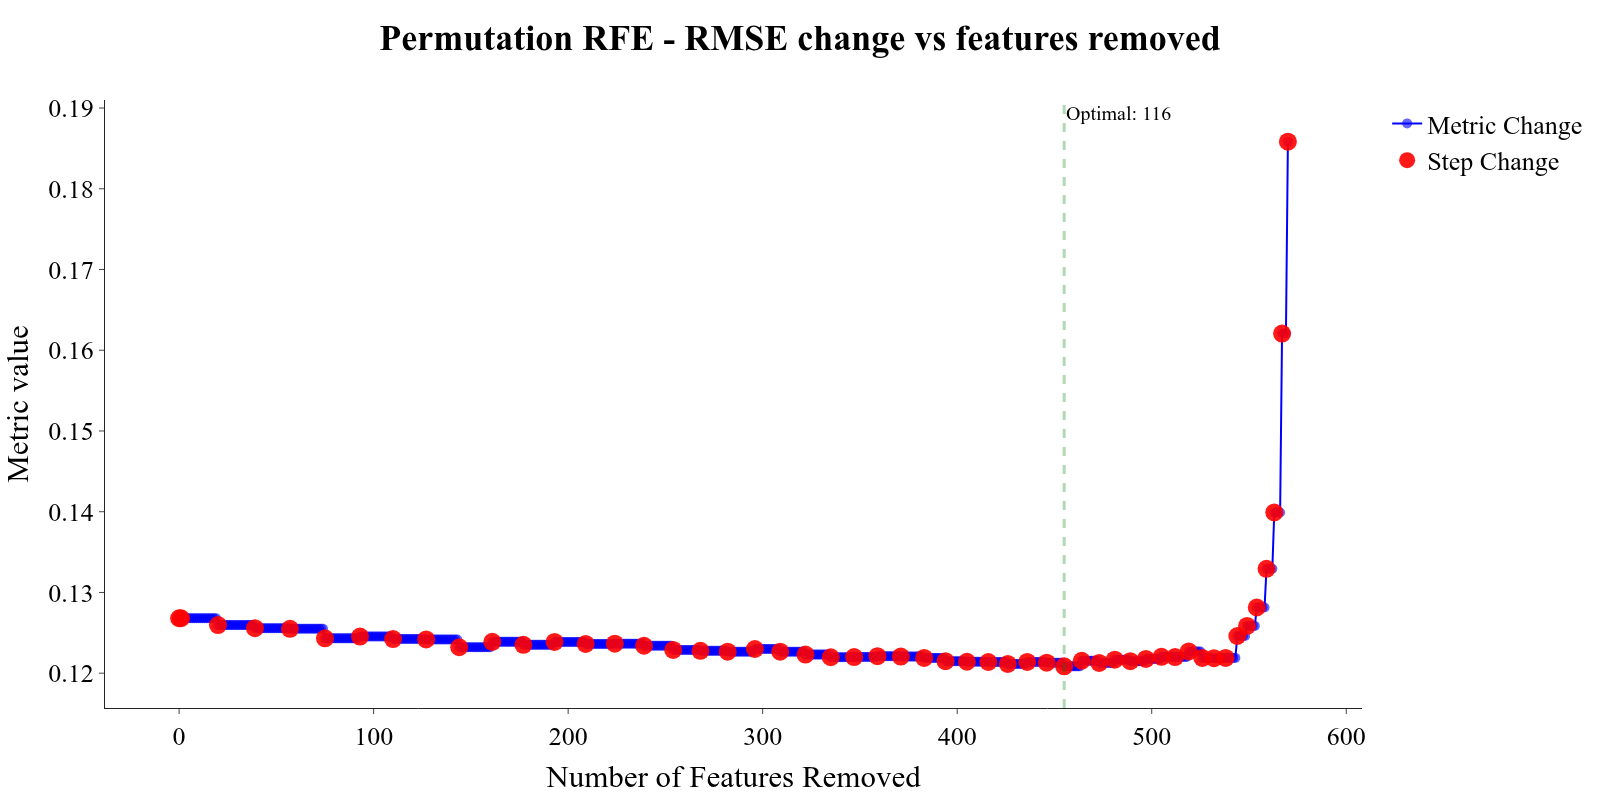

Number of features selected: 116
Selected features: ['1STFLRSF', '1STFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', '1STFLRSF_PREPROCESS_KBINS_500', '2NDFLRSF_PREPROCESS_DIGIT_1', 'BASEMENT_TO_LIVING_AREA_RATIO', 'BEDROOMABVGR_PREPROCESS_CNT_FREQ', 'BEDROOM_TO_ROOM_RATIO', 'BEDROOM_TO_ROOM_RATIO_PREPROCESS_DIGIT_N3_PREPROCESS_CNT_FREQ', 'BSMTEXPOSURE', 'BSMTEXPOSURE_ORDINAL', 'BSMTEXPOSURE_PREPROCESS_CNT_FREQ', 'BSMTEXPOSURE_PREPROCESS_TARGET_ENC', 'BSMTFINSF1', 'BSMTFINSF1_PREPROCESS_DIGIT_0', 'BSMTFINSF1_PREPROCESS_DIGIT_2', 'BSMTFINSF1_PREPROCESS_KBINS_500', 'BSMTFINTYPE1', 'BSMTFINTYPE1_ORDINAL', 'BSMTUNFSF', 'BSMTUNFSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', 'BSMTUNFSF_PREPROCESS_KBINS_500', 'CENTRALAIR', 'CENTRALAIR_PREPROCESS_TARGET_ENC', 'CONDITION1', 'CONDITION1_PREPROCESS_CNT_FREQ', 'CONDITION1_PREPROCESS_TARGET_ENC', 'EXTERIOR1ST', 'EXTERIOR2ND', 'FIREPLACEQU_ORDINAL', 'FIREPLACEQU_PREPROCESS_TARGET_ENC', 'FIREPLACES_PREPROCESS_TARGET_ENC', 'FUNCTIONAL', 'FUNCTIONAL_ORD

In [18]:
permutation_rfe = PermutationRecursiveFeatureElimination(
    estimator=feature_selection_model,
    cross_validator=cross_validation_trainer,
    steps=50,
    alpha=0.99,
    n_repeats=10,
    verbose=True,
    protected_features=[],
)
permutation_rfe_summary = permutation_rfe.run(train_data[independent_features], train_data[TARGET_FEATURE])
permutation_rfe_summary_history = permutation_rfe_summary["history"].copy()
permutation_rfe_selected_features = permutation_rfe_summary["selected_features"].copy()
other_plots.plot_metric_change_vs_features_removed(permutation_rfe_summary_history, optimal_n_features=len(permutation_rfe_selected_features), plot_title=f"Permutation RFE - {METRIC_NAME} change vs features removed")
print(f"Number of features selected: {len(permutation_rfe_selected_features)}")
print(f"Selected features: {permutation_rfe_selected_features}")

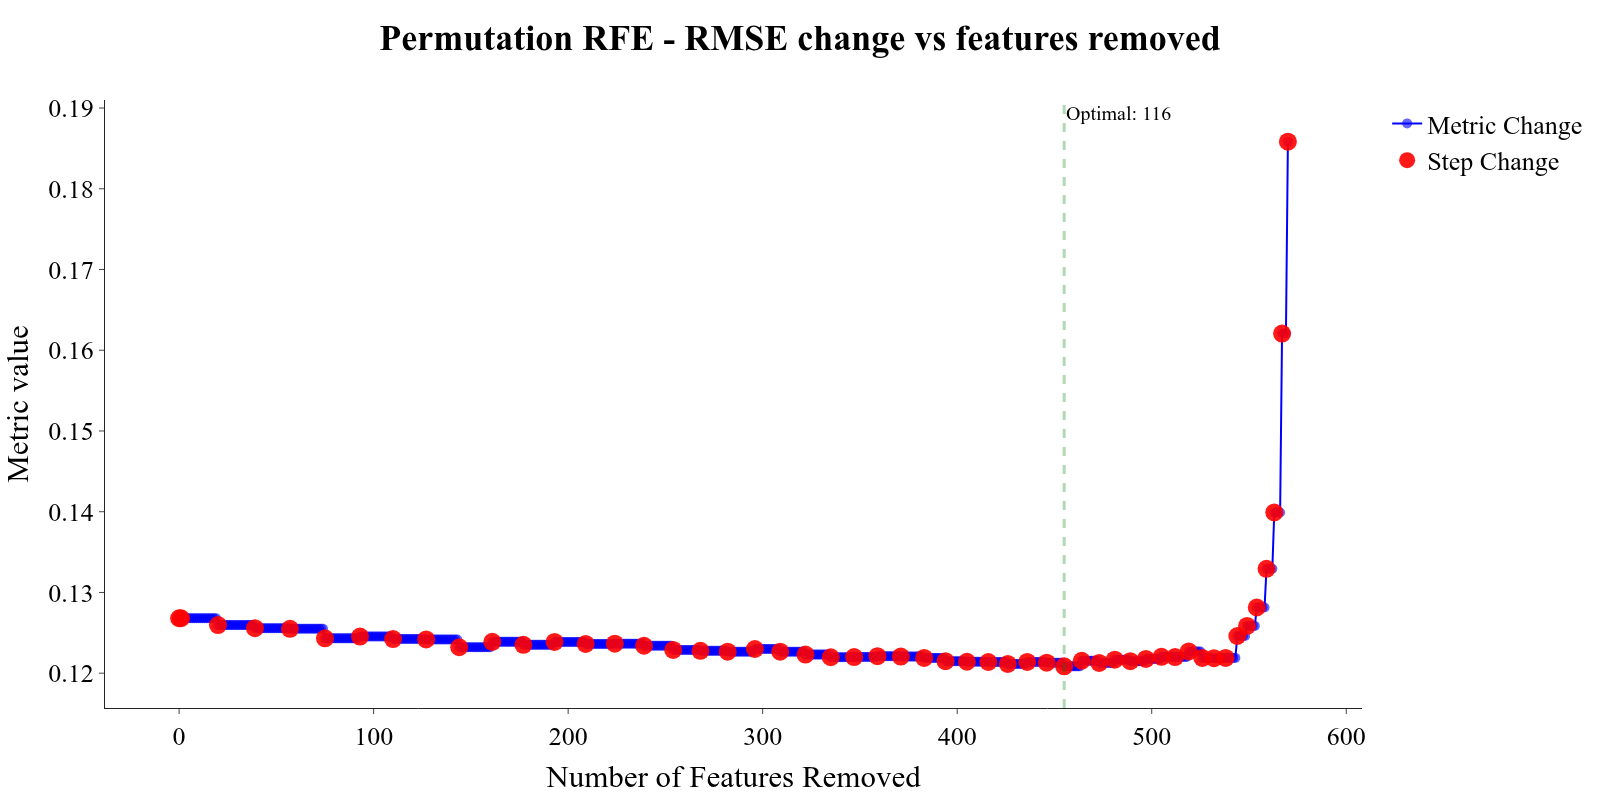

Number of features selected: 116
Selected features: ['1STFLRSF', '1STFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', '1STFLRSF_PREPROCESS_KBINS_500', '2NDFLRSF_PREPROCESS_DIGIT_1', 'BASEMENT_TO_LIVING_AREA_RATIO', 'BEDROOMABVGR_PREPROCESS_CNT_FREQ', 'BEDROOM_TO_ROOM_RATIO', 'BEDROOM_TO_ROOM_RATIO_PREPROCESS_DIGIT_N3_PREPROCESS_CNT_FREQ', 'BSMTEXPOSURE', 'BSMTEXPOSURE_ORDINAL', 'BSMTEXPOSURE_PREPROCESS_CNT_FREQ', 'BSMTEXPOSURE_PREPROCESS_TARGET_ENC', 'BSMTFINSF1', 'BSMTFINSF1_PREPROCESS_DIGIT_0', 'BSMTFINSF1_PREPROCESS_DIGIT_2', 'BSMTFINSF1_PREPROCESS_KBINS_500', 'BSMTFINTYPE1', 'BSMTFINTYPE1_ORDINAL', 'BSMTUNFSF', 'BSMTUNFSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', 'BSMTUNFSF_PREPROCESS_KBINS_500', 'CENTRALAIR', 'CENTRALAIR_PREPROCESS_TARGET_ENC', 'CONDITION1', 'CONDITION1_PREPROCESS_CNT_FREQ', 'CONDITION1_PREPROCESS_TARGET_ENC', 'EXTERIOR1ST', 'EXTERIOR2ND', 'FIREPLACEQU_ORDINAL', 'FIREPLACEQU_PREPROCESS_TARGET_ENC', 'FIREPLACES_PREPROCESS_TARGET_ENC', 'FUNCTIONAL', 'FUNCTIONAL_ORD

In [19]:
permutation_rfe_selected_features, metric_value = (permutation_rfe.select_features_weighted_score(permutation_rfe_summary_history, alpha=0.99))
other_plots.plot_metric_change_vs_features_removed( permutation_rfe_summary_history, optimal_n_features=len(permutation_rfe_selected_features), plot_title=f"Permutation RFE - {cross_validation_trainer.metric_name} change vs features removed", )
print(f"Number of features selected: {len(permutation_rfe_selected_features)}")
print(f"Selected features: {permutation_rfe_selected_features}")
print(f"{METRIC_NAME} after feature selection: {metric_value:.6f}")

In [20]:
preprocessing_pipeline = build_restricted_pipeline(preprocessing_pipeline, X_train, y=y_train, selected_features=permutation_rfe_selected_features)
cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, preprocessing_pipeline=preprocessing_pipeline, cv=CV, verbose=False)

In [21]:
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=feature_selection_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0303 +- 0.0100
Validation RMSE: 0.1208 +- 0.0050


# Baseline modeling

In [22]:
cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, preprocessing_pipeline=preprocessing_pipeline, cv=CV, verbose=True)

### LightGBM

In [23]:
lgbm_model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=80,
    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,
    reg_alpha=0.15,
    reg_lambda=1.50,
    max_bin=255,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
    deterministic=True,
    force_col_wise=True,
    importance_type="gain",
    early_stopping_round=100
)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=lgbm_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

[50]	training's rmse: 0.17441	valid_1's rmse: 0.179778
[100]	training's rmse: 0.129082	valid_1's rmse: 0.14201
[150]	training's rmse: 0.11471	valid_1's rmse: 0.132735
[200]	training's rmse: 0.106141	valid_1's rmse: 0.129397
[250]	training's rmse: 0.0992776	valid_1's rmse: 0.127845
[300]	training's rmse: 0.0936721	valid_1's rmse: 0.127077
[350]	training's rmse: 0.0885571	valid_1's rmse: 0.126176
[400]	training's rmse: 0.0844247	valid_1's rmse: 0.125646
[450]	training's rmse: 0.0806394	valid_1's rmse: 0.125267
[500]	training's rmse: 0.0773447	valid_1's rmse: 0.124953
[550]	training's rmse: 0.074145	valid_1's rmse: 0.125072
[600]	training's rmse: 0.071185	valid_1's rmse: 0.124752
[650]	training's rmse: 0.0684062	valid_1's rmse: 0.125075
[700]	training's rmse: 0.0657441	valid_1's rmse: 0.125056
Fold 1: train=0.07096 | valid=0.12467
[50]	training's rmse: 0.176064	valid_1's rmse: 0.168735
[100]	training's rmse: 0.130702	valid_1's rmse: 0.134402
[150]	training's rmse: 0.115875	valid_1's rmse:

### XGBoost

In [24]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=6.0,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=2.0,
    gamma=0.0,
    max_bin=256,
    enable_categorical=True,
    tree_method="hist",
    device="cuda",
    random_state=SEED,
    n_jobs=-1,
    early_stopping_rounds=50,
)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=xgb_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

[0]	validation_0-rmse:0.38909	validation_1-rmse:0.39052
[50]	validation_0-rmse:0.13143	validation_1-rmse:0.16789
[100]	validation_0-rmse:0.06507	validation_1-rmse:0.13145
[150]	validation_0-rmse:0.04271	validation_1-rmse:0.12520
[200]	validation_0-rmse:0.03313	validation_1-rmse:0.12311
[250]	validation_0-rmse:0.02697	validation_1-rmse:0.12226
[300]	validation_0-rmse:0.02241	validation_1-rmse:0.12203
[350]	validation_0-rmse:0.01823	validation_1-rmse:0.12188
[400]	validation_0-rmse:0.01469	validation_1-rmse:0.12186
[422]	validation_0-rmse:0.01352	validation_1-rmse:0.12187
Fold 1: train=0.01659 | valid=0.12179
[0]	validation_0-rmse:0.39103	validation_1-rmse:0.38335
[50]	validation_0-rmse:0.13220	validation_1-rmse:0.16200
[100]	validation_0-rmse:0.06519	validation_1-rmse:0.13403
[150]	validation_0-rmse:0.04267	validation_1-rmse:0.13060
[200]	validation_0-rmse:0.03225	validation_1-rmse:0.12981
[250]	validation_0-rmse:0.02573	validation_1-rmse:0.12919
[300]	validation_0-rmse:0.02061	validati

### CatBoost

### Ensemble model

In [25]:
cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, preprocessing_pipeline=preprocessing_pipeline, cv=CV, verbose=False)

In [26]:
estimators = [lgbm_model, xgb_model]

ensemble_model = EnsembleModel(estimators=estimators, problem_type=PROBLEM_TYPE)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0303 +- 0.0100
Validation RMSE: 0.1208 +- 0.0050


## Ensemble wights tuning

In [27]:
ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators=estimators,
    cross_validator=cross_validation_trainer,
    n_trials=N_TRIALS * 5,
    seed=SEED,
    allow_negative_weights=False,
)
ensemble_weights_tuner.tune(
    train_data[independent_features], train_data[TARGET_FEATURE]
)
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(
        f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}"
    )

🔍 Starting ensemble weight search with 500 trials via cross-validation, target metric: RMSE (minimize).
🎛️  Blending 2 estimators: ['LGBMRegressor', 'XGBRegressor']
[EnsembleWeightTunerCV] LGBMRegressor OOF RMSE: 0.12383 +- 0.00555
[EnsembleWeightTunerCV] XGBRegressor OOF RMSE: 0.12587 +- 0.00490
🌟 Trial 1/500 | RMSE: 0.123353 | Best: 0.123353 (trial 1) | 0.00s | weights: [0.5, 0.5]
🔁 Trial 2/500 | RMSE: 0.126603 | Best: 0.123353 (trial 1) | 0.00s | weights: [1.0, 0.0]
🔁 Trial 3/500 | RMSE: 0.128322 | Best: 0.123353 (trial 1) | 0.00s | weights: [0.0, 1.0]
🔁 Trial 4/500 | RMSE: 0.123950 | Best: 0.123353 (trial 1) | 0.00s | weights: [0.3571, 0.6429]
🔁 Trial 5/500 | RMSE: 0.123875 | Best: 0.123353 (trial 1) | 0.00s | weights: [0.7383, 0.2617]
🌟 Trial 6/500 | RMSE: 0.123305 | Best: 0.123305 (trial 6) | 0.00s | weights: [0.5453, 0.4547]
🔁 Trial 7/500 | RMSE: 0.123318 | Best: 0.123305 (trial 6) | 0.00s | weights: [0.5255, 0.4745]
🔁 Trial 8/500 | RMSE: 0.126721 | Best: 0.123305 (trial 6) | 0.

In [28]:
ensemble_model = EnsembleModel( estimators=ensemble_weights_tuner.estimators, problem_type=PROBLEM_TYPE, weights=ensemble_weights_tuner.best_weights, )
train_scores, valid_scores, _ = cross_validation_trainer.fit( estimator=ensemble_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE], )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

Train RMSE: 0.0327 +- 0.0105
Validation RMSE: 0.1208 +- 0.0050


In [29]:
final_model = ensemble_model

# Evaluation

In [30]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.1, random_state=SEED, shuffle=True)

In [31]:
X_train_temp = train_data_temp.drop(columns=[TARGET_FEATURE]).copy()
y_train_temp = train_data_temp[TARGET_FEATURE]
X_test_temp = test_data_temp.drop(columns=[TARGET_FEATURE], errors="ignore").copy()
y_test_temp = test_data_temp[TARGET_FEATURE] if TARGET_FEATURE in test_data_temp.columns else None

X_train_temp_transformed = preprocessing_pipeline.fit_transform(X=X_train_temp, y=y_train_temp)
X_test_temp_transformed = preprocessing_pipeline.transform(X=X_test_temp)

final_model.fit( X_train_temp_transformed, y_train_temp, eval_set=[(X_test_temp_transformed, y_test_temp)],)

y_train_pred = final_model.predict(X_train_temp_transformed)
y_test_pred = final_model.predict(X_test_temp_transformed)

In [32]:
regression_results(y_train_true=y_train_temp, y_train_pred=y_train_pred, y_test_true=y_test_temp, y_test_pred=y_test_pred)

,MAE,MedAE,MSE,RMSE,MAPE,R²,Explained Var
Train,0.0392,0.0268,0.0038,0.0612,0.33%,0.9764,0.9764
Test,0.0906,0.0674,0.0152,0.1233,0.75%,0.9076,0.9076


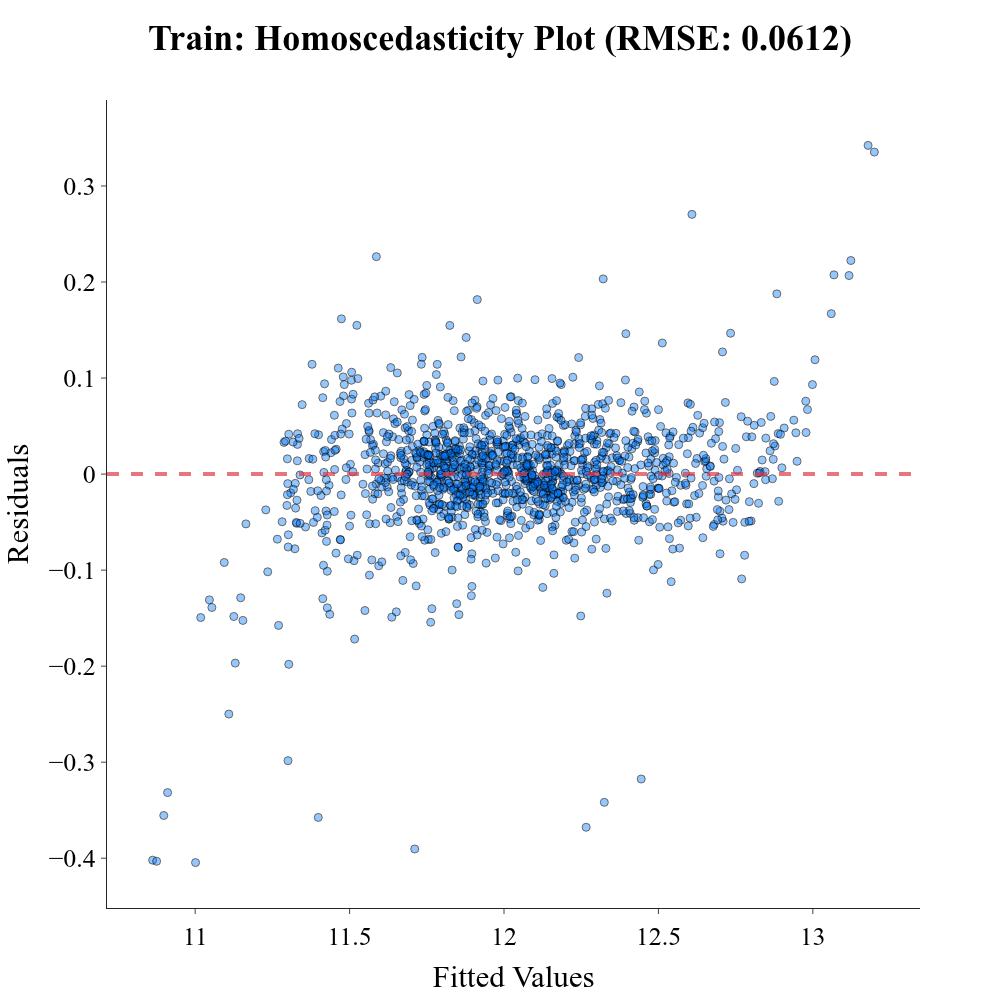

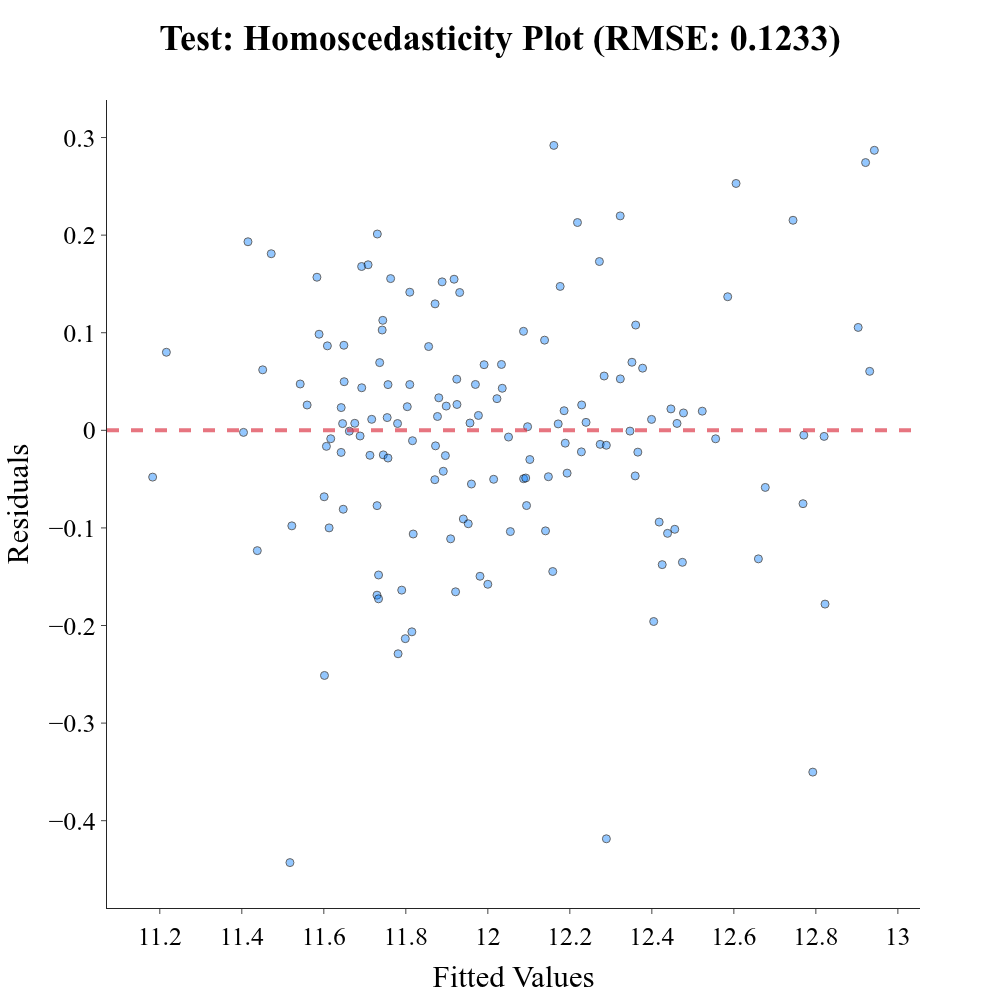

In [33]:
regression_plots.homoscedacity_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title="Train: Homoscedasticity Plot", metric_name="RMSE")
regression_plots.homoscedacity_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title="Test: Homoscedasticity Plot", metric_name="RMSE")

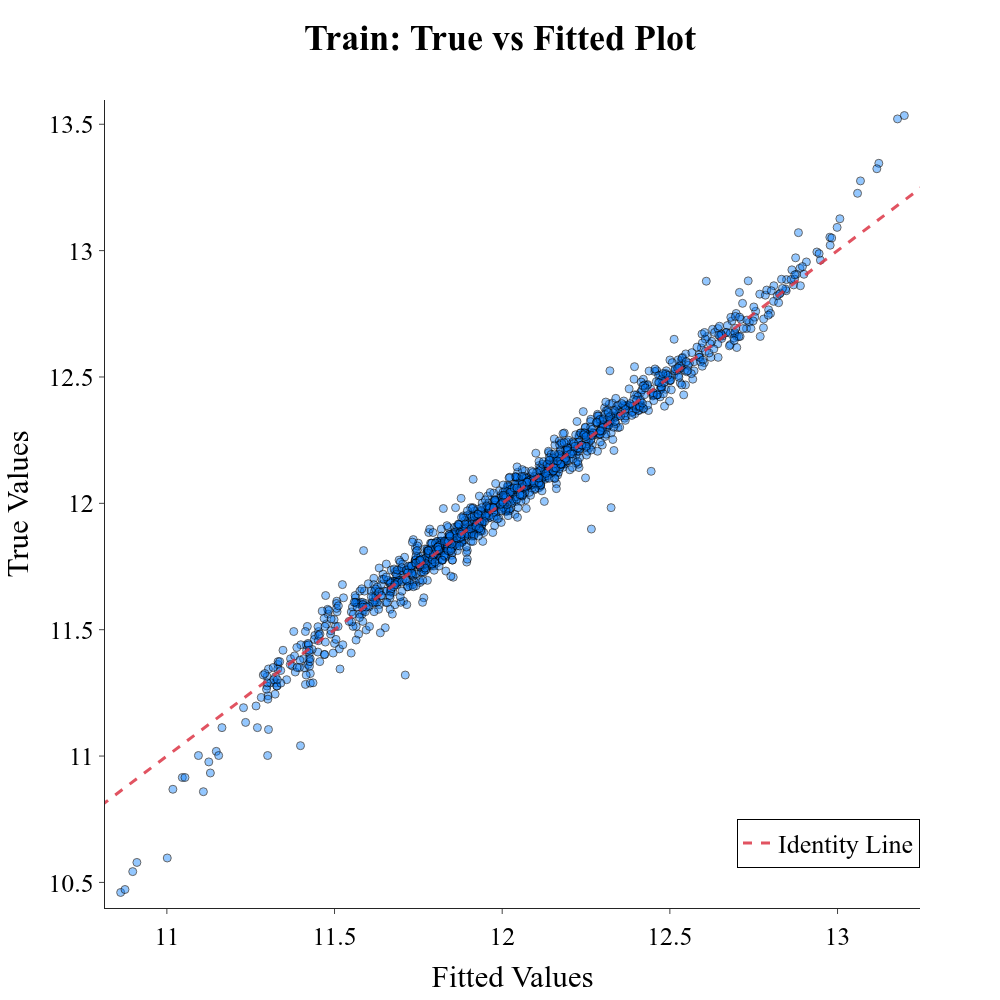

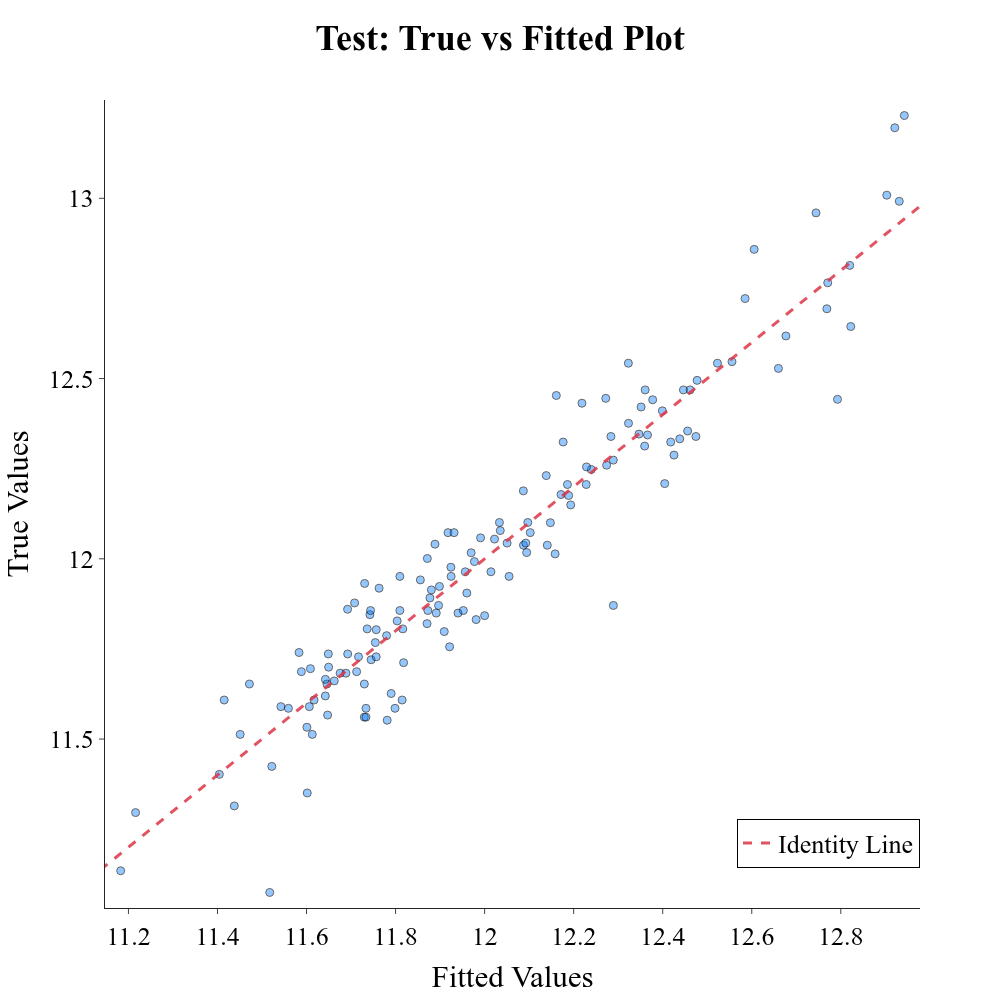

In [34]:
regression_plots.true_vs_fitted_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title="Train: True vs Fitted Plot", metric_name="RMSE")
regression_plots.true_vs_fitted_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title="Test: True vs Fitted Plot", metric_name="RMSE")

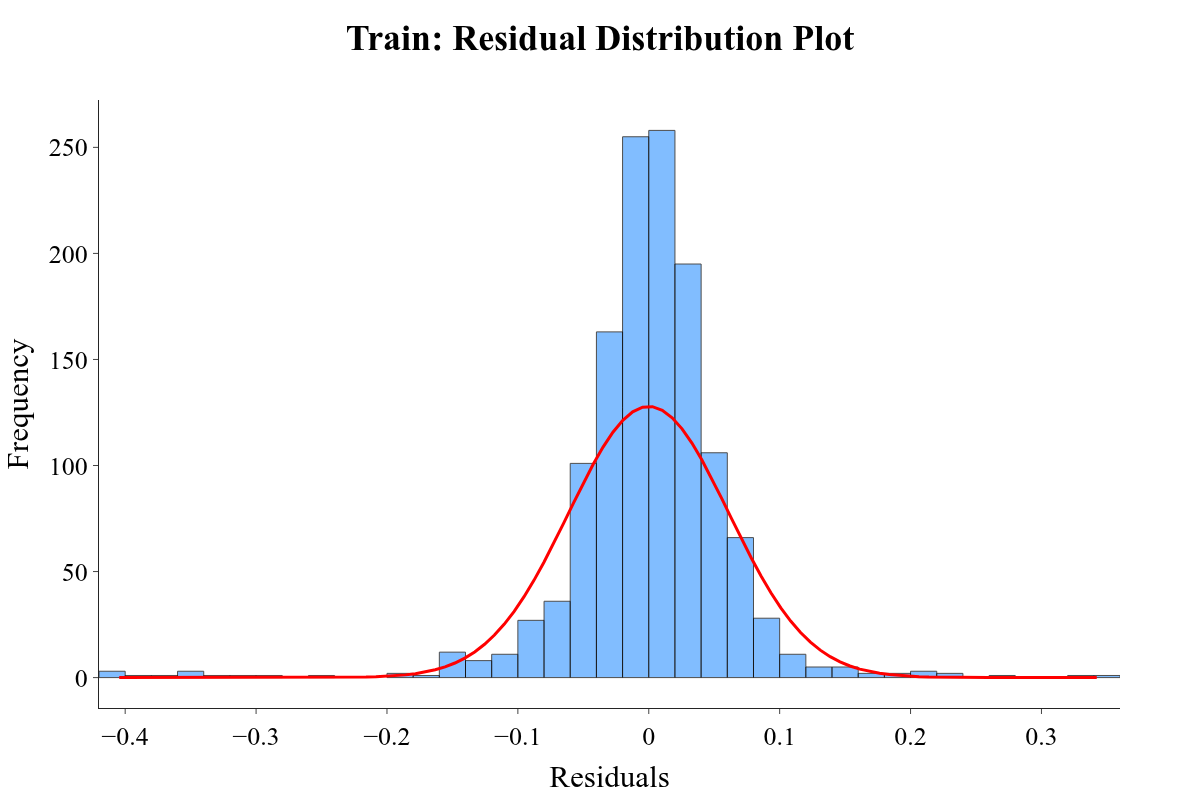

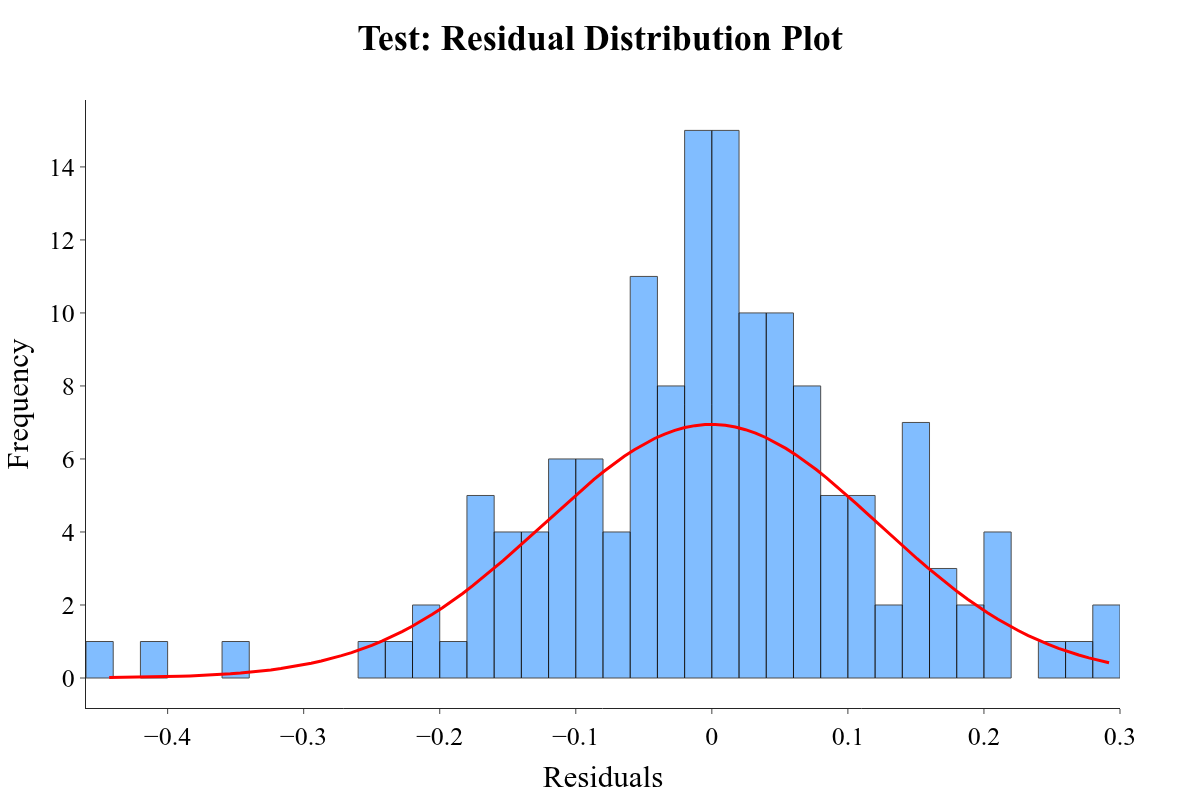

In [35]:
regression_plots.residual_distribution_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title="Train: Residual Distribution Plot", metric_name="RMSE")
regression_plots.residual_distribution_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title="Test: Residual Distribution Plot", metric_name="RMSE")

## Feature importance

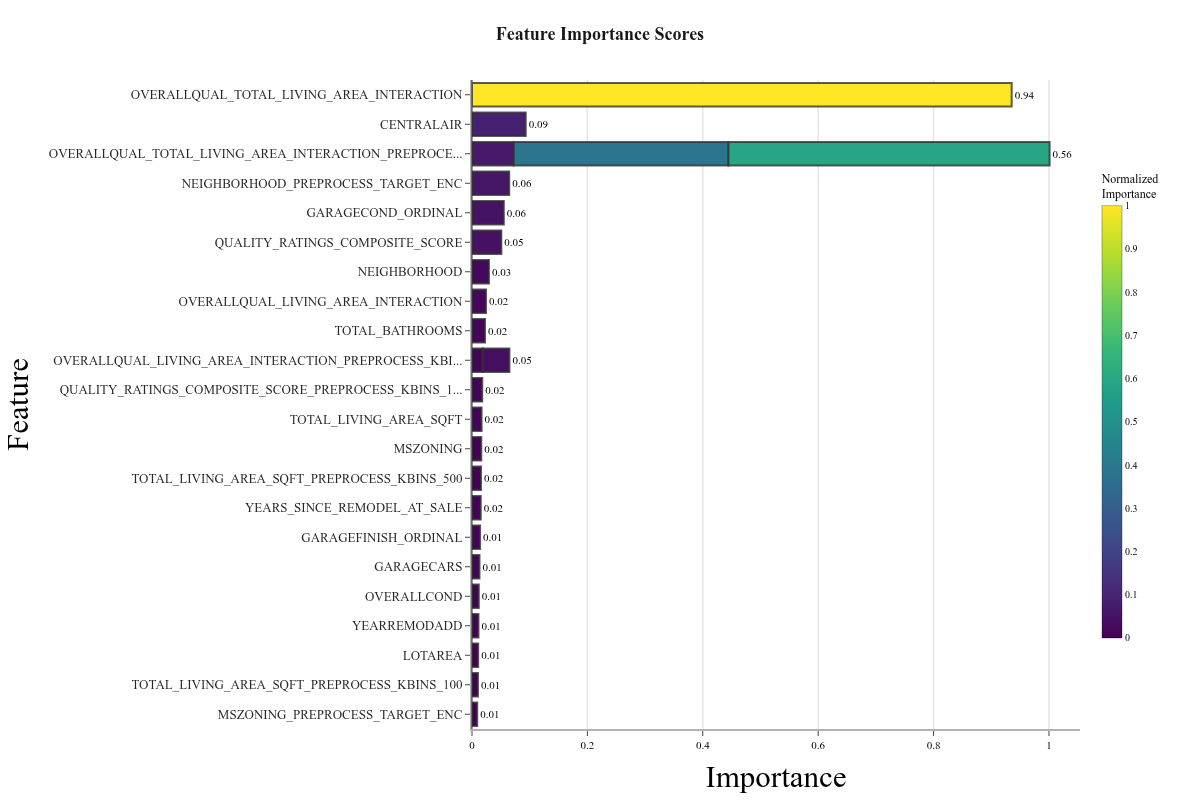

In [36]:
feature_importance_df = pd.DataFrame(
    {
        "feature": X_train_temp_transformed.columns,
        "importance": final_model.feature_importances_,
    }
).sort_values(by="importance", ascending=False)
other_plots.feature_importance_plot(feature_importance_df.set_index("feature")["importance"].to_dict(), plot_title="Feature Importance Scores", top_n=25)

### SHAP values

In [37]:
shap_values = compute_shap_values(final_model, X_test_temp_transformed)

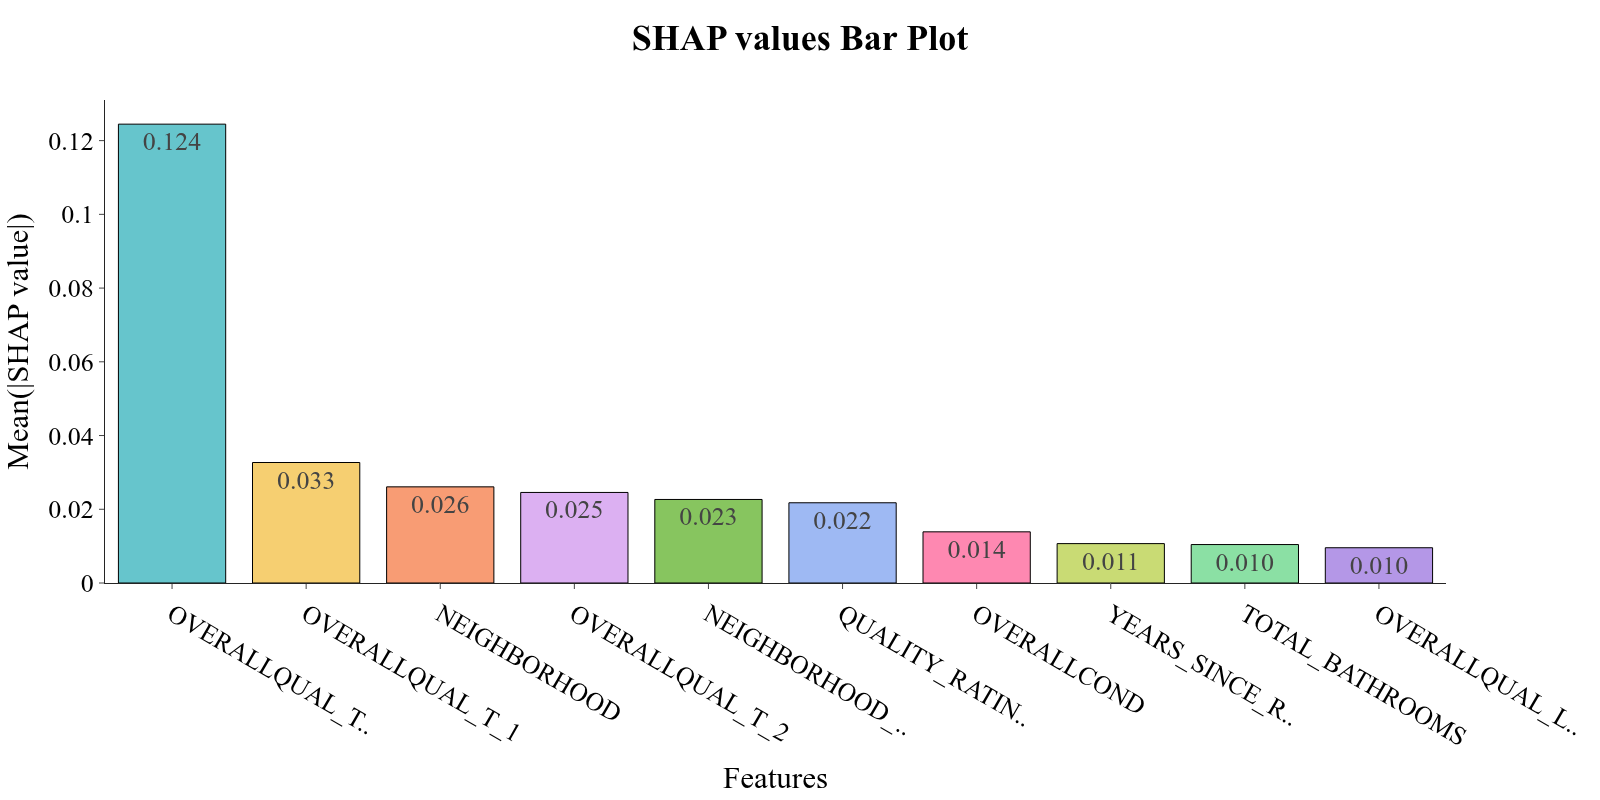

In [38]:
shap_plots.plot_shap_bar(shap_values=shap_values, top_n=10, plot_title="SHAP values Bar Plot")

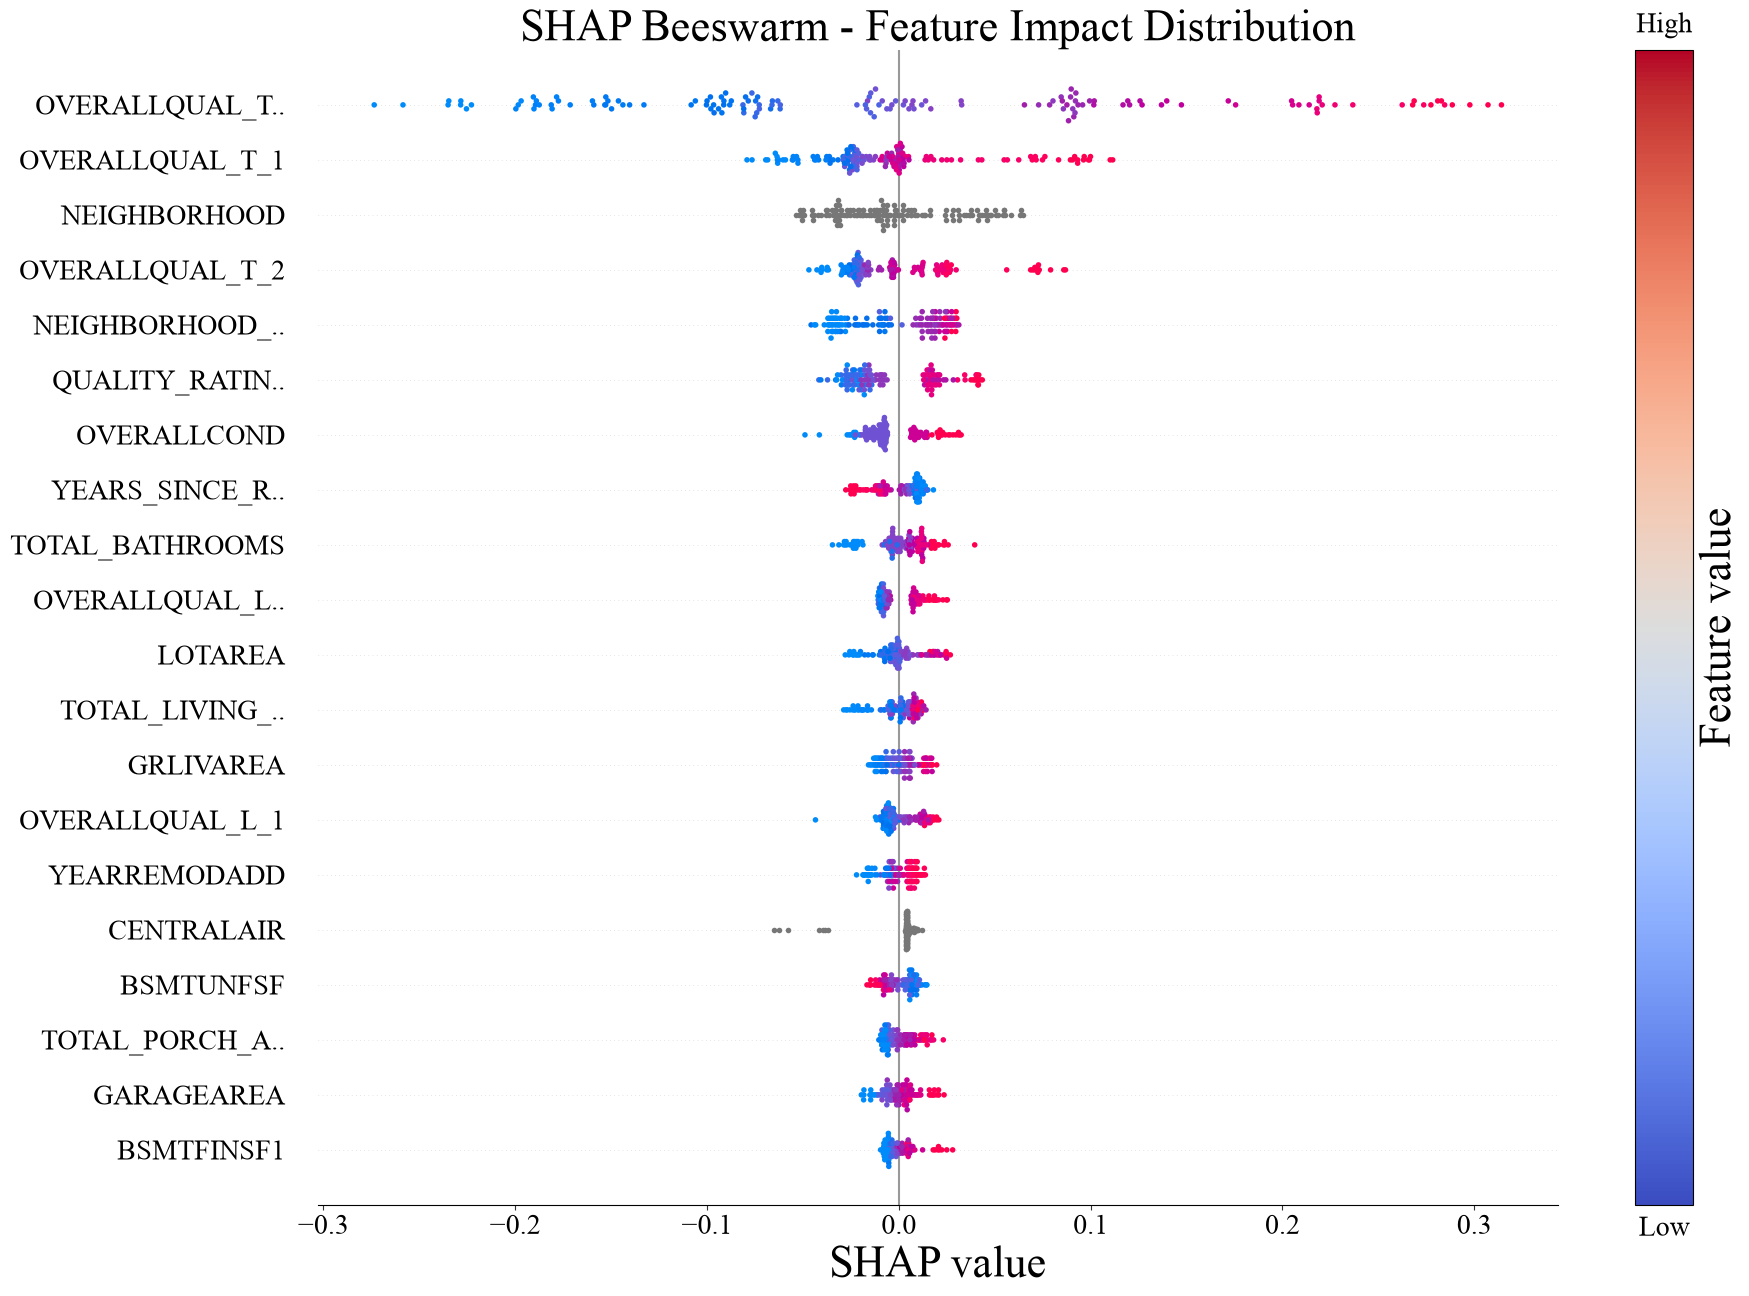

In [39]:
%matplotlib inline
shap_plots.plot_custom_shap_beeswarm(shap_values=shap_values, top_n=20, plot_title="SHAP Beeswarm - Feature Impact Distribution")

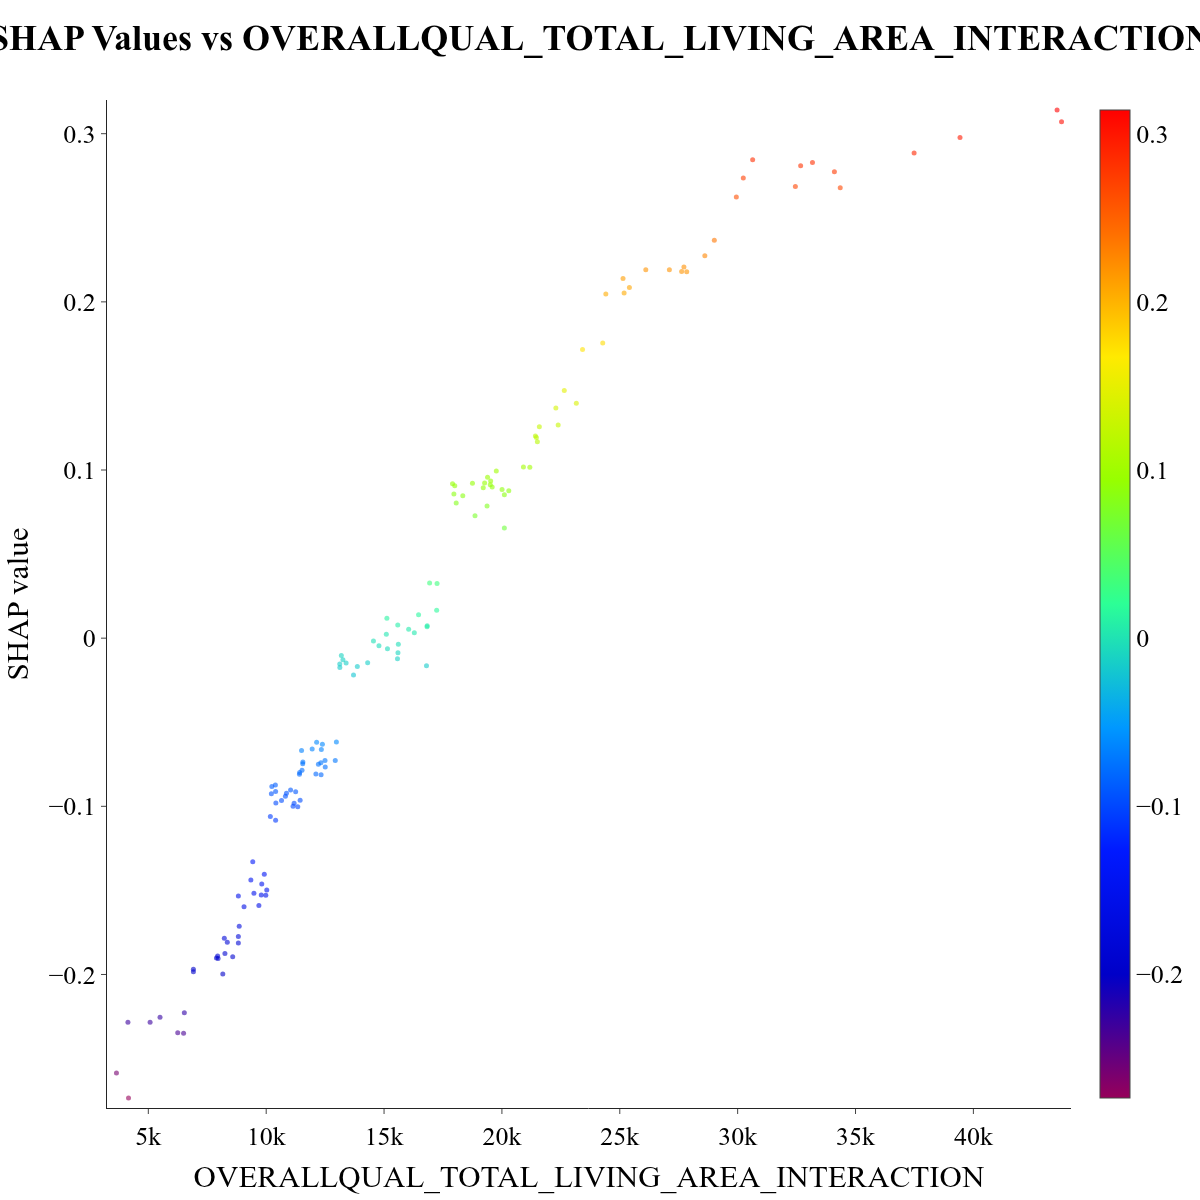

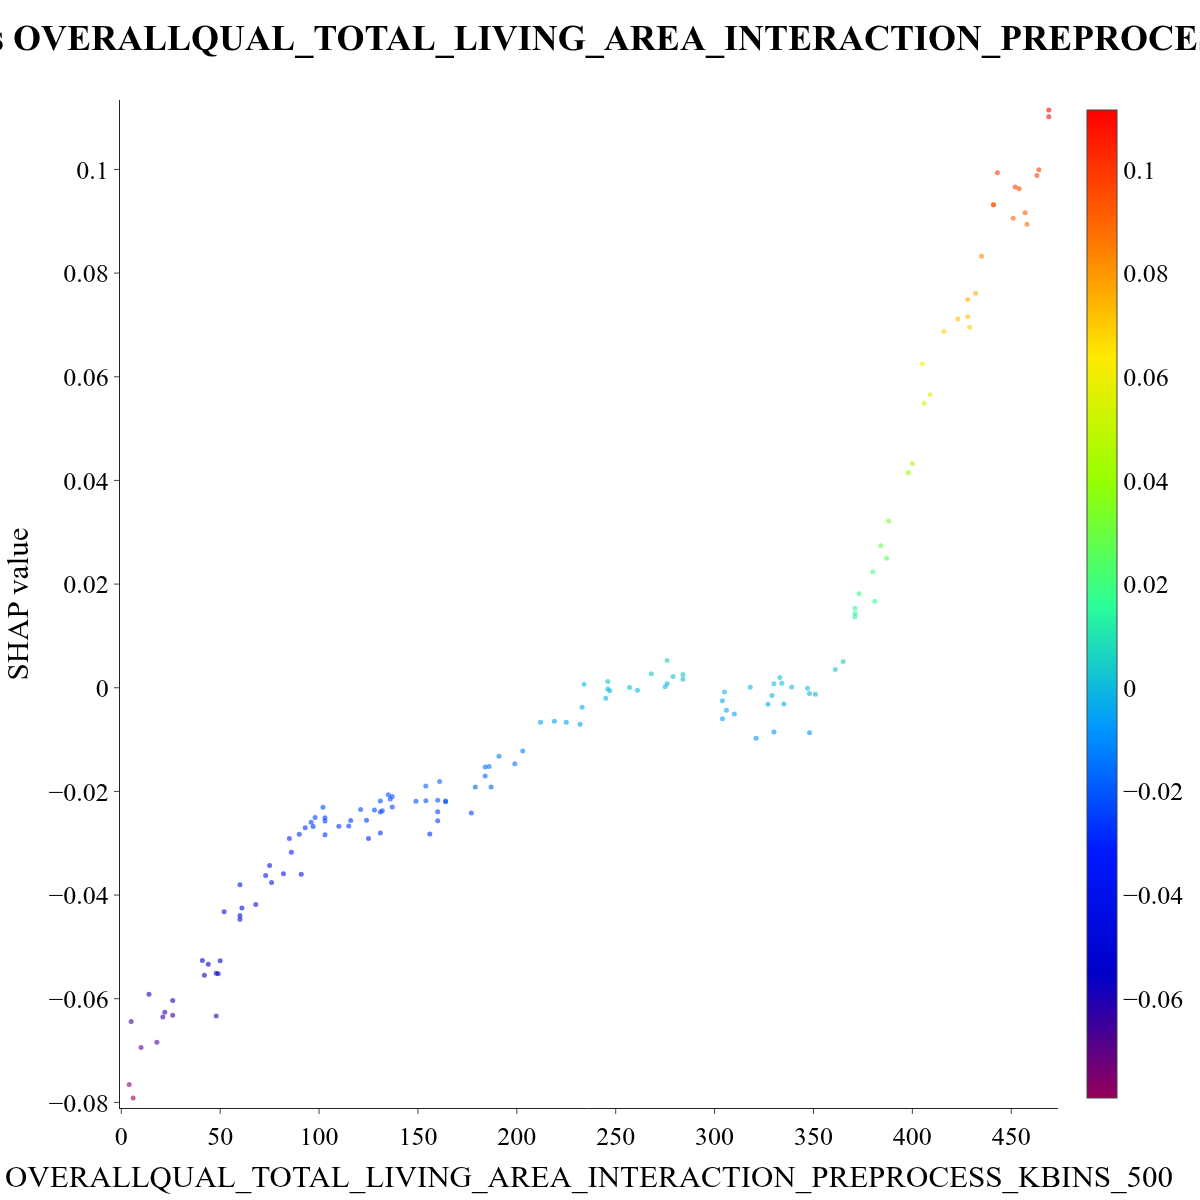

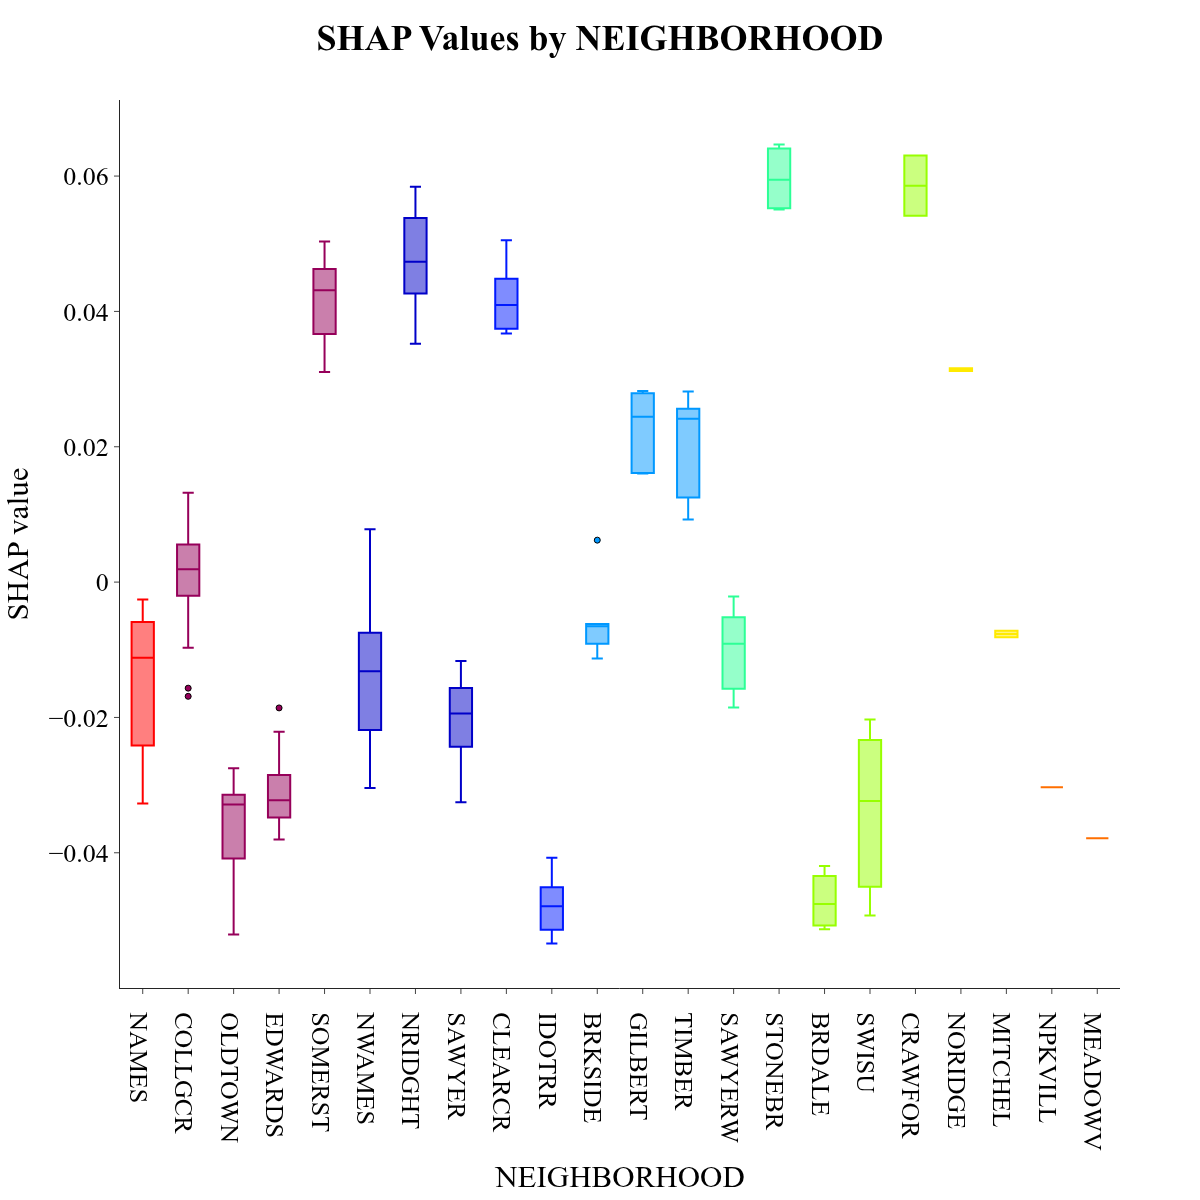

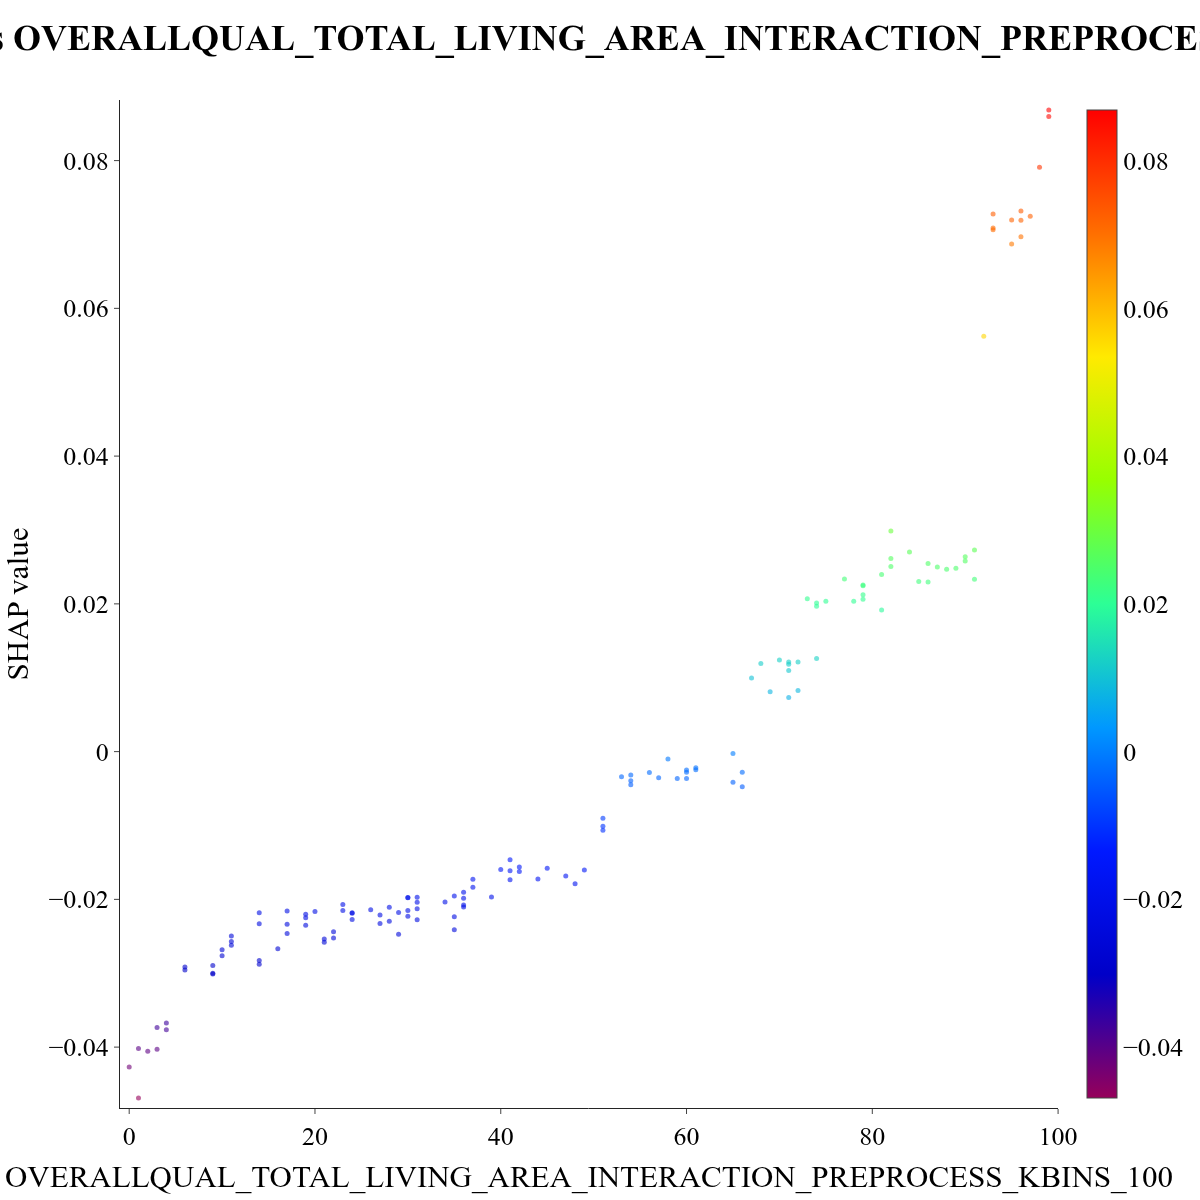

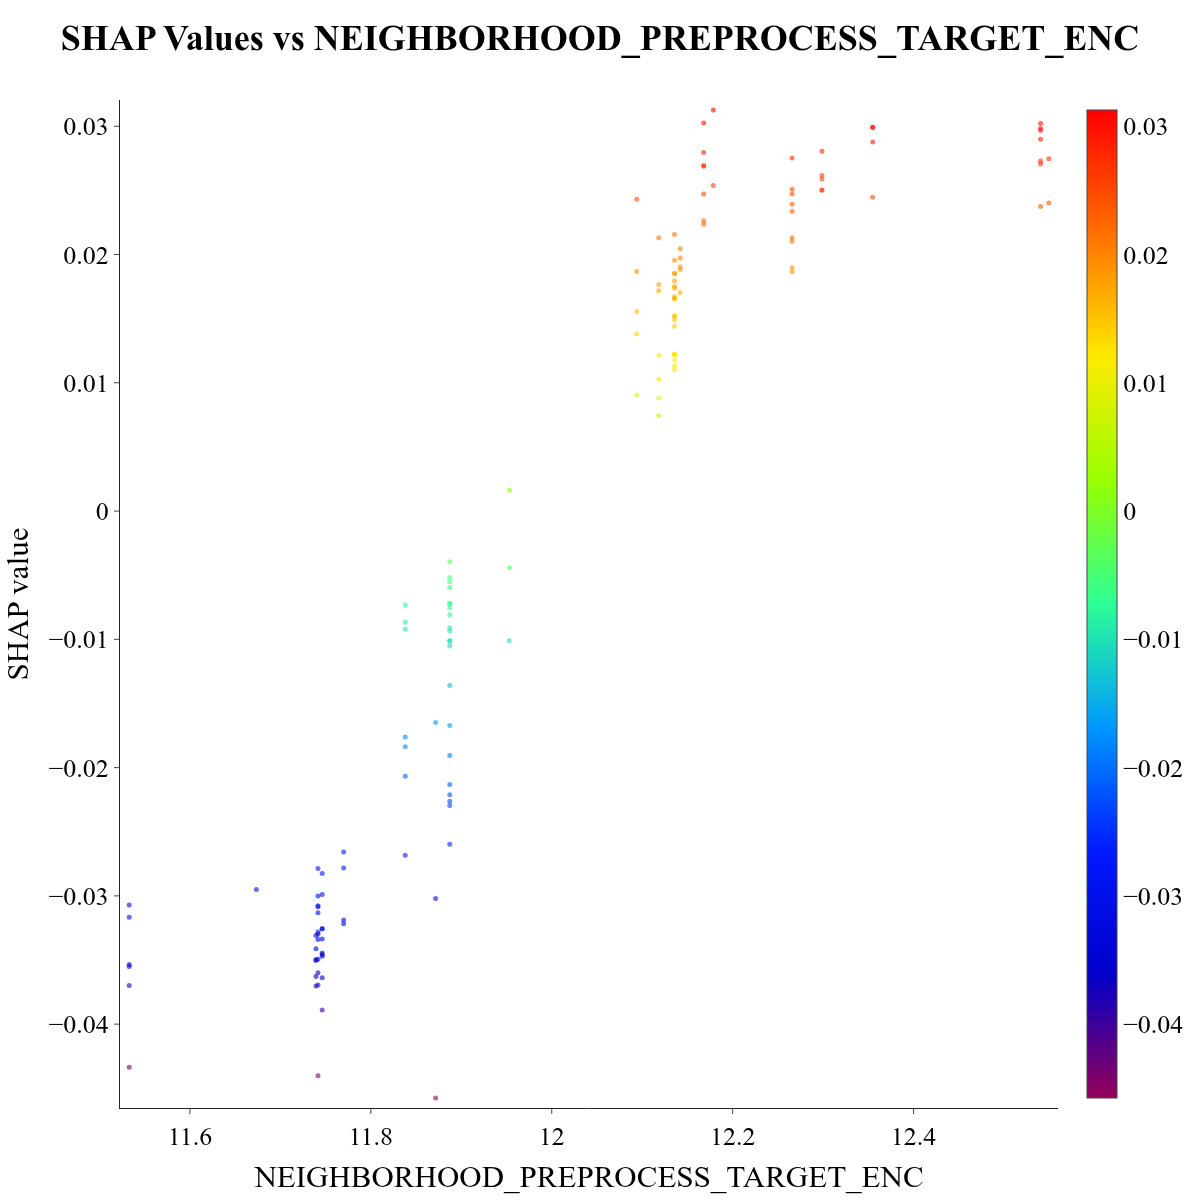

In [40]:
_, top_features, top_shap_mean_values = shap_plots._compute_shap_importance(
    shap_values, top_n=5
)
for feature in top_features:
    scatter = shap_values[:, feature]
    if X_test_transformed[feature].dtype.name == 'category':
        shap_plots.plot_shap_categorical_box(scatter, feature)
    else:
        shap_plots.plot_shap_numerical_scatter(scatter, feature)

# Final Submission

In [41]:
def submit_to_kaggle(predictions: np.ndarray, submission_data: pd.DataFrame, competition_name: str, message: str = "Submission") -> None:
    """
    Submits predictions to a Kaggle competition.
    
    Args:
        predictions (np.ndarray): Array of predictions to submit.
        submission_data (pd.DataFrame): DataFrame containing the submission format.
        competition_name (str): Name of the Kaggle competition.
        message (str): Submission message.
    """
    api = KaggleApi()
    api.authenticate()
    submission_data[submission_data.columns[1]] = predictions
    submission_data.to_csv("submission.csv", index=False)
    api.competition_submit(file_name="submission.csv", message=message, competition=competition_name)
    display(submission_data.head())

submission_data = pd.read_csv("data/sample_submission.csv")

In [42]:
def inverse_transform_predictions(predictions: np.ndarray) -> np.ndarray:
    """
    Inverse transforms predictions that were log-transformed using np.log1p.
    
    Args:
        predictions (np.ndarray): Array of log-transformed predictions.
    
    Returns:
        np.ndarray: Array of predictions in the original scale.
    """
    return np.expm1(predictions)

## Submission (traditional approach)

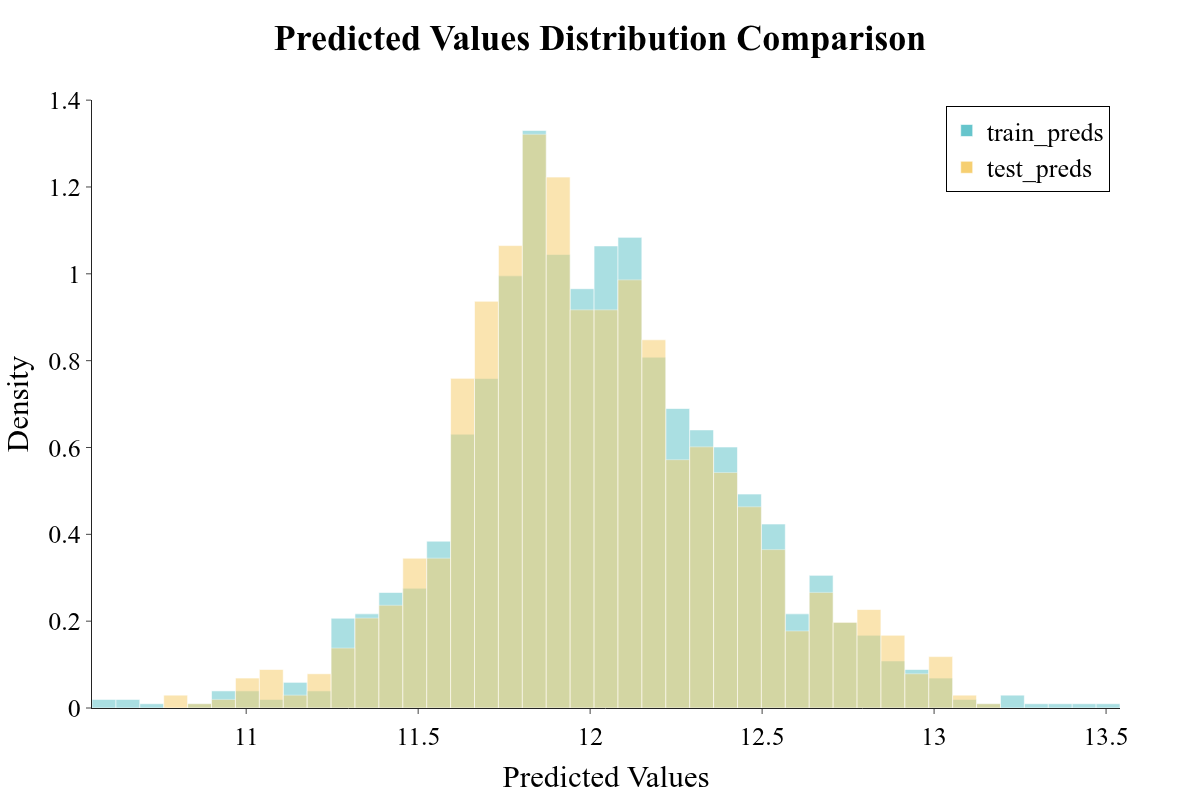

100%|██████████| 33.7k/33.7k [00:00<00:00, 81.9kB/s]


,Id,SalePrice
0,1461,119684.990053
1,1462,163811.468597
2,1463,180727.024440
3,1464,191890.677768
4,1465,176236.672203


In [43]:
def disable_early_stopping(estimator: object) -> object:
    """
    Disable early stopping for supported estimators.

    Args:
        estimator (object): The estimator to modify.

    Returns:
        object: The estimator with early stopping disabled.
    """
    if hasattr(estimator, "early_stopping_round"):
        estimator.set_params(early_stopping_round=None)
    elif hasattr(estimator, "early_stopping"):
        if "LGBM" in estimator.__class__.__name__:
            estimator.set_params(early_stopping=None)
        elif "HistGradientBoosting" in estimator.__class__.__name__:
            estimator.set_params(early_stopping=False)
    elif hasattr(estimator, "early_stopping_rounds"):
        estimator.set_params(early_stopping_rounds=None)
    return estimator

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train_transformed = preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test_transformed = preprocessing_pipeline.transform(X=X_test)

final_model_no_early_stopping = deepcopy(final_model)
if hasattr(final_model_no_early_stopping, "estimators"):
    final_model_no_early_stopping.estimators = [ disable_early_stopping(est) for est in final_model_no_early_stopping.estimators ]
else:
    final_model_no_early_stopping = disable_early_stopping( final_model_no_early_stopping )

final_model_no_early_stopping.fit( X_train_transformed, y_train)
train_preds = final_model_no_early_stopping.predict( X_train_transformed )
test_preds = final_model_no_early_stopping.predict( X_test_transformed )
continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle( predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (traditional approach)", )

## Submission (validation set approach)

In [44]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.1, random_state=SEED, shuffle=True)
X_train_temp = train_data_temp.drop(columns=[TARGET_FEATURE]).copy()
y_train_temp = train_data_temp[TARGET_FEATURE]
X_test_temp = test_data_temp.drop(columns=[TARGET_FEATURE], errors="ignore").copy()
y_test_temp = test_data_temp[TARGET_FEATURE]

X_train_temp_transformed = preprocessing_pipeline.fit_transform(X=X_train_temp, y=y_train_temp)
X_test_temp_transformed = preprocessing_pipeline.transform(X=X_test_temp)

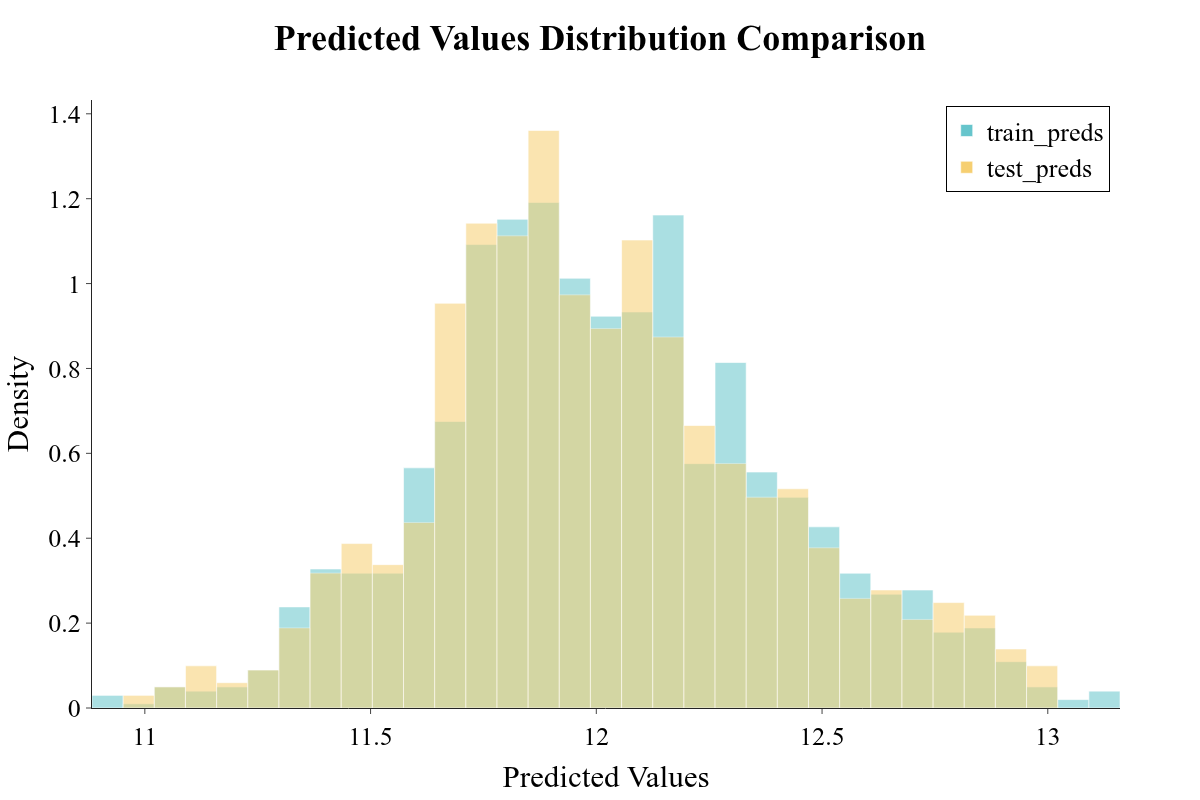

100%|██████████| 33.6k/33.6k [00:00<00:00, 83.9kB/s]


,Id,SalePrice
0,1461,118473.152649
1,1462,163927.028268
2,1463,176681.081067
3,1464,189834.261146
4,1465,183270.609841


In [45]:
final_model.fit( X_train_temp_transformed, y_train_temp, eval_set=[(X_test_temp_transformed, y_test_temp)])
train_preds = final_model.predict( X_train_transformed )
test_preds = final_model.predict( X_test_transformed )

continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle( predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (with early stopping)", )

## Submission (OOF approach)

Train RMSE: 0.0327 +- 0.0105
Validation RMSE: 0.1208 +- 0.0050


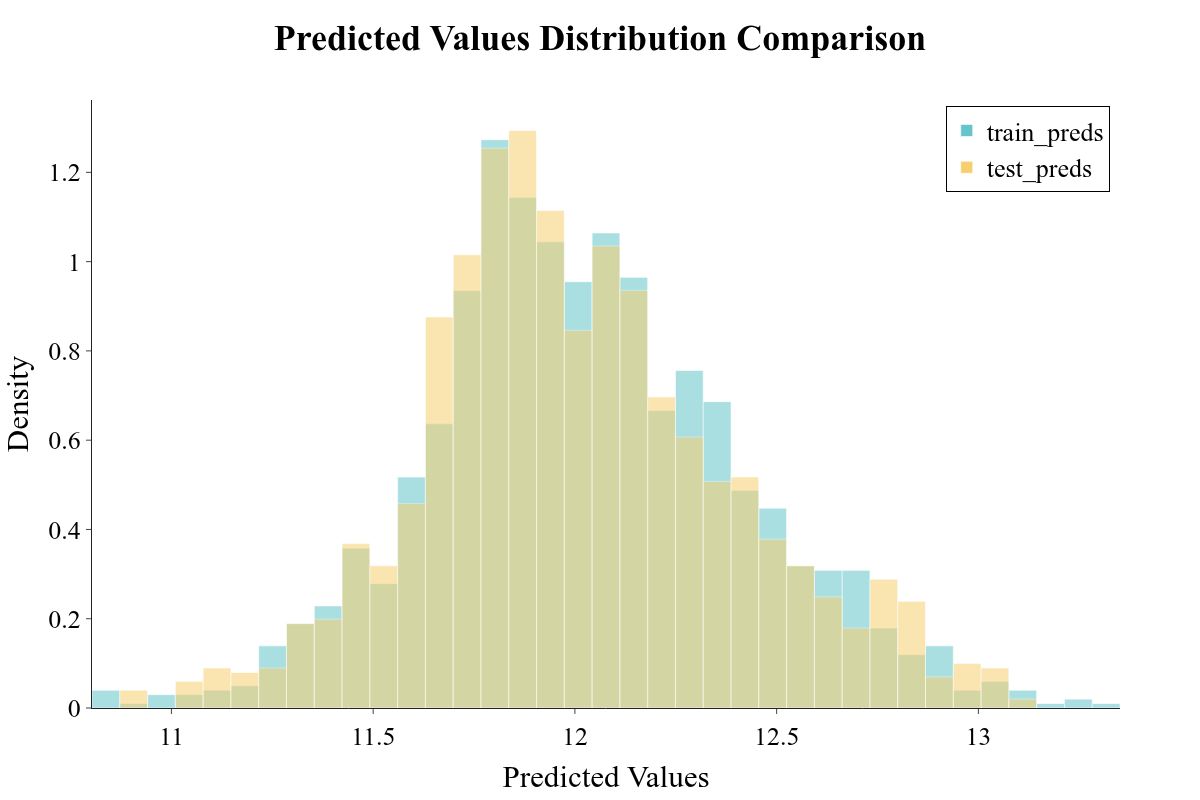

100%|██████████| 33.6k/33.6k [00:00<00:00, 66.9kB/s]


,Id,SalePrice
0,1461,123320.140270
1,1462,161041.075382
2,1463,180282.470368
3,1464,191410.346694
4,1465,180697.044352


In [46]:
cross_validation_trainer = CrossValidationTrainer(
    metric_name=METRIC_NAME,
    problem_type=PROBLEM_TYPE,
    preprocessing_pipeline=preprocessing_pipeline,
    cv=CV,
    verbose=False,
)

train_scores, valid_scores, avg_test_pred = cross_validation_trainer.fit( estimator=deepcopy(final_model), X=train_data[independent_features], y=train_data[TARGET_FEATURE], X_test=test_data[independent_features], )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

train_preds = cross_validation_trainer.predict(X=train_data[independent_features])
test_preds = avg_test_pred
continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle(predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (OOF predictions)", )

In [47]:
print(f"SELECTED_FEATURES = {sorted(preprocessing_pipeline[-1].kw_args['features'])}")

SELECTED_FEATURES = ['1STFLRSF', '1STFLRSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', '1STFLRSF_PREPROCESS_KBINS_500', '2NDFLRSF_PREPROCESS_DIGIT_1', 'BASEMENT_TO_LIVING_AREA_RATIO', 'BEDROOMABVGR_PREPROCESS_CNT_FREQ', 'BEDROOM_TO_ROOM_RATIO', 'BEDROOM_TO_ROOM_RATIO_PREPROCESS_DIGIT_N3_PREPROCESS_CNT_FREQ', 'BSMTEXPOSURE', 'BSMTEXPOSURE_ORDINAL', 'BSMTEXPOSURE_PREPROCESS_CNT_FREQ', 'BSMTEXPOSURE_PREPROCESS_TARGET_ENC', 'BSMTFINSF1', 'BSMTFINSF1_PREPROCESS_DIGIT_0', 'BSMTFINSF1_PREPROCESS_DIGIT_2', 'BSMTFINSF1_PREPROCESS_KBINS_500', 'BSMTFINTYPE1', 'BSMTFINTYPE1_ORDINAL', 'BSMTUNFSF', 'BSMTUNFSF_PREPROCESS_DIGIT_3_PREPROCESS_TARGET_ENC', 'BSMTUNFSF_PREPROCESS_KBINS_500', 'CENTRALAIR', 'CENTRALAIR_PREPROCESS_TARGET_ENC', 'CONDITION1', 'CONDITION1_PREPROCESS_CNT_FREQ', 'CONDITION1_PREPROCESS_TARGET_ENC', 'EXTERIOR1ST', 'EXTERIOR2ND', 'FIREPLACEQU_ORDINAL', 'FIREPLACEQU_PREPROCESS_TARGET_ENC', 'FIREPLACES_PREPROCESS_TARGET_ENC', 'FUNCTIONAL', 'FUNCTIONAL_ORDINAL', 'GARAGEAREA', 'GARAGEAREA